# Prognose von Aktienkursen mittels maschinellen Lernens am Beispiel der NVIDIA-Aktie

**Begleit-Notebook zur Seminar-/Termpaper-Arbeit**

---

Dieses Notebook implementiert den im Exposé beschriebenen Untersuchungsablauf
end-to-end und folgt dabei der dort vorgeschlagenen Gliederung. Im Mittelpunkt
steht die zentrale Forschungsfrage:

> **Inwieweit lässt sich der zukünftige Schlusskurs der NVIDIA-Aktie auf Basis
> historischer Kurssequenzen mithilfe eines LSTM-Modells prognostizieren, und
> erzielt dieses Modell eine messbar bessere Prognosegüte als naive
> Referenzverfahren?**

Der Aufbau orientiert sich an der Gliederung des Exposés:

| Kapitel | Inhalt |
|---|---|
| **0** | Setup, Bibliotheken, Reproduzierbarkeit |
| **3** | Datengrundlage & Datenqualitätsprüfung (Data Cleaning) |
| **4** | Explorative Datenanalyse (Deskriptiv, Rendite, Stationarität/ADF, Volumen, Ereignisse) |
| **5** | Datenvorverarbeitung & Feature Engineering (Skalierung, Sliding-Window) |
| **6** | Modellierung: Referenzmodelle, **Auto-ARIMA/SARIMA** & **LSTM mit Hyperparameter-Suche** |
| **7** | Evaluation (MAE/RMSE/R²/MAPE/sMAPE/Theil-U) & Explainability (SHAP) |
| **8** | Diskussion & kritische Einordnung |
| **9** | Fazit & Ausblick |

> **Hinweis zur Methodik:** Ein wesentlicher Beitrag dieser Arbeit liegt nicht
> allein in der erreichten Prognosegenauigkeit, sondern in der *kritischen
> Einordnung*: Wir prüfen explizit, ob das LSTM einen substanziellen Mehrwert
> gegenüber der naiven Baseline („morgen = heute") liefert – oder ob seine
> Vorhersagen im Wesentlichen einer zeitlich verzögerten Fortschreibung des
> Vortageskurses entsprechen.

## 0  Setup und Reproduzierbarkeit

Wir laden alle benötigten Bibliotheken und fixieren globale Zufalls-Seeds, damit
die Ergebnisse reproduzierbar sind. Einige Komponenten sind **optional**:

* **TensorFlow/Keras** – für das LSTM-Modell. Fehlt das Paket, weicht das
  Notebook automatisch auf einen funktional vergleichbaren MLP-Ersatz
  (`scikit-learn`) aus, sodass das Notebook dennoch vollständig durchläuft.
* **SHAP** – für die Explainability. Fehlt das Paket (oder schlägt die
  SHAP-Berechnung fehl), wird eine modell-agnostische Permutationswichtigkeit
  als Fallback verwendet.

Die Kernpakete (`numpy`, `pandas`, `scikit-learn`, `statsmodels`, `matplotlib`,
`yfinance`) werden in `requirements.txt` gepinnt.

### 0.1  Zentrale Konfiguration

Alle steuerenden Parameter des Experiments sind **an einem einzigen Ort**
definiert. Wer den Suchraum, den Zeitraum, die Feature-Auswahl oder die
Modellarchitektur anpassen möchte, muss **nur diese Zelle bearbeiten** —
der gesamte Rest des Notebooks bezieht seine Einstellungen von hier.

In [1]:
# ============================================================================
# KONFIGURATION — alle steuerenden Parameter an einem Ort
# ============================================================================

# --- Reproduzierbarkeit & Daten ---------------------------------------------
SEED       = 42
TICKER     = "NVDA"
START_DATE = "2015-01-01"
END_DATE   = "2024-12-31"

# --- Features & Zielvariable ------------------------------------------------
FEATURES = ["Close", "LogReturn", "MA_Ratio", "Volatility20", "Volume_z", "Weekday",
            "RSI14", "MACD", "BB_Pct"]
TARGET   = "Close"

# --- Zeitlicher Split (chronologisch: Train / Val / Test) -------------------
SPLIT_TRAIN = 0.70   # 70 % Training
SPLIT_VAL   = 0.85   # 85 % Training + Validierung  =>  15 % Val, 15 % Test

# --- Sliding-Window ---------------------------------------------------------
WINDOW = 60          # Länge des Eingabefensters in Handelstagen

# --- ARIMA / SARIMA — Suchraum ----------------------------------------------
ARIMA_M                   = 5              # Saisonperiode (Handelswoche = 5 Tage)
ARIMA_P_RANGE             = range(0, 5)
ARIMA_D_RANGE             = [1, 2]
ARIMA_Q_RANGE             = range(0, 5)
ARIMA_SEASONAL_CANDIDATES = [(1, 0, 0, ARIMA_M),
                              (0, 0, 1, ARIMA_M),
                              (1, 0, 1, ARIMA_M)]

# --- LSTM — Training & Hyperparameter-Suchraum ------------------------------
BATCH         = 32
SEARCH_EPOCHS = 25
FINAL_EPOCHS  = 60

LSTM_SEARCH_SPACE = [
    {"units": (32,),         "dropout": 0.10, "lr": 1e-3},   # 1 Schicht, schmal
    {"units": (64,),         "dropout": 0.20, "lr": 1e-3},   # 1 Schicht, breiter
    {"units": (128,),        "dropout": 0.20, "lr": 1e-3},   # 1 Schicht, breit
    {"units": (64, 32),      "dropout": 0.20, "lr": 1e-3},   # 2 Schichten
    {"units": (128, 64),     "dropout": 0.30, "lr": 1e-3},   # 2 Schichten, breit
    {"units": (128, 64),     "dropout": 0.20, "lr": 5e-4},   # 2 Schichten, kleinere LR
    {"units": (64, 32),      "dropout": 0.30, "lr": 5e-4},   # 2 Schichten, mehr Dropout
    {"units": (128, 64, 32), "dropout": 0.30, "lr": 5e-4},   # 3 Schichten, tief
]

print("Konfiguration geladen:")
print(f"  Ticker / Zeitraum  : {TICKER}  {START_DATE} – {END_DATE}")
print(f"  SEED               : {SEED}")
print(f"  Features ({len(FEATURES)})       : {FEATURES}")
print(f"  Fenstergröße       : {WINDOW} Handelstage")
_pct = (int(SPLIT_TRAIN*100), int((SPLIT_VAL-SPLIT_TRAIN)*100), int((1-SPLIT_VAL)*100))
print(f"  Split              : {_pct[0]} / {_pct[1]} / {_pct[2]} %  (Train / Val / Test)")
print(f"  ARIMA-Gitter       : p∈{list(ARIMA_P_RANGE)} × d∈{ARIMA_D_RANGE} × q∈{list(ARIMA_Q_RANGE)}")
print(f"  LSTM-Kandidaten    : {len(LSTM_SEARCH_SPACE)} Konfigurationen")

Konfiguration geladen:
  Ticker / Zeitraum  : NVDA  2015-01-01 – 2024-12-31
  SEED               : 42
  Features (9)       : ['Close', 'LogReturn', 'MA_Ratio', 'Volatility20', 'Volume_z', 'Weekday', 'RSI14', 'MACD', 'BB_Pct']
  Fenstergröße       : 60 Handelstage
  Split              : 70 / 15 / 15 %  (Train / Val / Test)
  ARIMA-Gitter       : p∈[0, 1, 2, 3, 4] × d∈[1, 2] × q∈[0, 1, 2, 3, 4]
  LSTM-Kandidaten    : 8 Konfigurationen


In [2]:
# --- Kernbibliotheken -------------------------------------------------------
import warnings, sys, random, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline

# --- Statistik / Zeitreihen -------------------------------------------------
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# --- Machine Learning -------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

# --- Reproduzierbarkeit (SEED aus Konfigurationszelle) ----------------------
random.seed(SEED); np.random.seed(SEED)

# --- Optional: TensorFlow / Keras ------------------------------------------
HAS_TF = False
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TF = True
except Exception as e:
    print("TensorFlow nicht verfügbar -> MLP-Ersatzmodell wird genutzt:", e)

# --- Optional: SHAP ---------------------------------------------------------
HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
except Exception as e:
    print("SHAP nicht verfügbar -> Permutationswichtigkeit als Fallback:", e)

# --- tqdm (Fortschrittsbalken) — stiller Fallback falls nicht installiert ---
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it   # transparenter no-op

# --- Optional: Plotly (interaktive Visualisierungen) ------------------------
HAS_PLOTLY = False
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    HAS_PLOTLY = True
except Exception as e:
    print("Plotly nicht verfügbar -> interaktive Zelle (Kap. 7.2d) wird übersprungen:", e)

# --- Darstellung ------------------------------------------------------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy/Pandas: {np.__version__} / {pd.__version__}")
print(f"TensorFlow  : {'verfügbar' if HAS_TF else 'NICHT verfügbar (Fallback aktiv)'}")
print(f"SHAP        : {'verfügbar' if HAS_SHAP else 'NICHT verfügbar (Fallback aktiv)'}")
print(f"Plotly      : {'verfügbar' if HAS_PLOTLY else 'NICHT verfügbar (interaktive Zelle übersprungen)'}")

I0000 00:00:1783019187.533282    2421 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python      : 3.11.15
NumPy/Pandas: 2.4.6 / 3.0.3
TensorFlow  : verfügbar
SHAP        : verfügbar
Plotly      : verfügbar


## 3  Datengrundlage und Datenaufbereitung

### 3.1  Datenquelle und Beschreibung des Datensatzes

Als Datengrundlage dienen historische Tageskursdaten der **NVIDIA-Aktie
(Ticker: `NVDA`)**, bezogen über **Yahoo Finance** (`yfinance`). Der Datensatz
umfasst Eröffnungs- und Schlusskurse (*Open*, *Close*), Tageshöchst- und
Tagestiefstkurse (*High*, *Low*), das Handelsvolumen (*Volume*) sowie die
zugehörigen Handelszeitstempel. Zentrale **Zielvariable** ist der Schlusskurs
(*Close*); die übrigen Variablen werden als mögliche Einflussgrößen geprüft.

> **Robustheit:** Steht keine Netzwerkverbindung zu Yahoo Finance zur Verfügung
> (z. B. in einer abgeschotteten Umgebung), erzeugt die Funktion einen
> **synthetischen, NVIDIA-ähnlichen Ersatzdatensatz** (geometrische Brownsche
> Bewegung mit Trend- und Volatilitätsregimen). Das Notebook bleibt dadurch
> jederzeit ausführbar; die Variable `DATA_SOURCE` dokumentiert, welche Quelle
> tatsächlich verwendet wurde. **Für belastbare wissenschaftliche Aussagen sind
> stets die echten Yahoo-Finance-Daten zu verwenden.**

In [3]:
def _synthetic_nvda(start, end, seed=SEED):
    """Synthetischer OHLCV-Ersatzdatensatz (nur Fallback ohne Netzwerk)."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates)
    # Driftendes Regime: moderater Trend, der sich in den Jahren beschleunigt
    t = np.linspace(0, 1, n)
    drift = 0.0004 + 0.0010 * t**2          # steigender Drift (KI-Boom-Analogie)
    vol   = 0.018 + 0.015 * (t > 0.6)        # Volatilitätsregime ab ~60% des Zeitraums
    shocks = rng.normal(0, 1, n)
    log_ret = drift + vol * shocks
    close = 5.0 * np.exp(np.cumsum(log_ret))  # Startniveau ~5 USD
    # OHLC aus Close ableiten
    daily_range = np.abs(rng.normal(0, 1, n)) * vol * close
    open_ = close * (1 + rng.normal(0, 0.004, n))
    high  = np.maximum(open_, close) + daily_range * 0.5
    low   = np.minimum(open_, close) - daily_range * 0.5
    volume = (rng.lognormal(mean=18.0, sigma=0.4, size=n)
              * (1 + 3 * (np.abs(log_ret) > 0.05))).astype(np.int64)
    df = pd.DataFrame({"Open": open_, "High": high, "Low": low,
                       "Close": close, "Volume": volume}, index=dates)
    df.index.name = "Date"
    return df

def _data_dir():
    return pathlib.Path.cwd() / "data"

def load_price_data(ticker=TICKER, start=START_DATE, end=END_DATE):
    """Lädt OHLCV-Daten von Yahoo Finance; Fallbacks: eingebettetes CSV-Snapshot,
    dann synthetischer Ersatzdatensatz."""
    source = "synthetic"
    df = None
    try:
        import yfinance as yf
        raw = yf.download(ticker, start=start, end=end,
                          progress=False, auto_adjust=True)
        if raw is not None and len(raw) > 0:
            # yfinance liefert bei Einzelticker teils MultiIndex-Spalten
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            cols = ["Open", "High", "Low", "Close", "Volume"]
            df = raw[cols].copy()
            df.index.name = "Date"
            source = "yfinance"
    except Exception as e:
        print("yfinance-Download fehlgeschlagen:", e)

    if df is None or len(df) == 0:
        snapshot_path = _data_dir() / "nvda_ohlcv.csv"
        if snapshot_path.is_file():
            print(f"==> Kein Live-Zugriff auf Yahoo Finance -> verwende CSV-Snapshot: {snapshot_path}")
            df = pd.read_csv(snapshot_path, index_col="Date", parse_dates=True)
            df = df.loc[(df.index >= start) & (df.index <= end)]
            if len(df) > 0:
                source = "csv_snapshot"
            else:
                df = None

    if df is None or len(df) == 0:
        print("==> Verwende synthetischen Ersatzdatensatz (kein Netzwerk-/Datenzugriff).")
        df = _synthetic_nvda(start, end)
    return df, source

df, DATA_SOURCE = load_price_data()
print(f"Datenquelle : {DATA_SOURCE}")
print(f"Zeitraum    : {df.index.min().date()}  bis  {df.index.max().date()}")
print(f"Beobachtungen: {len(df):,}")
df.head()

Datenquelle : yfinance
Zeitraum    : 2015-01-02  bis  2024-12-30
Beobachtungen: 2,515


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,0.4824,0.4860,0.4748,0.4824,113680000
2015-01-05,0.4824,0.4839,0.4721,0.4743,197952000
2015-01-06,0.4750,0.4755,0.4594,0.4599,197764000
2015-01-07,0.4633,0.4673,0.4573,0.4587,321808000
2015-01-08,0.4640,0.4788,0.4637,0.4760,283780000


### 3.2  Datenqualitätsprüfung und Data Cleaning

Vor jeder Analyse wird die Datenqualität systematisch geprüft und nachvollziehbar
dokumentiert. Geprüft werden:

1. **Fehlende Werte** (`NaN`) je Spalte,
2. **Duplikate** im Zeitindex,
3. **Zeitliche Konsistenz / Datenlücken** (Handelsunterbrechungen, Wochenenden,
   Feiertage – an Börsen sind Lücken normal und *keine* Fehler),
4. **Plausibilität / Ausreißer** (z. B. `High >= Low`, nicht-positive Kurse,
   extreme Tagesrenditen).

In [4]:
print("=== Datentypen & Nichtleere Werte ===")
df.info()

print("\n=== Fehlende Werte je Spalte ===")
print(df.isna().sum())

print("\n=== Duplikate im Index ===")
print(f"Doppelte Zeitstempel: {df.index.duplicated().sum()}")

# Plausibilitätschecks
neg_prices   = (df[["Open", "High", "Low", "Close"]] <= 0).any(axis=1).sum()
hl_violation = (df["High"] < df["Low"]).sum()
print(f"\nNicht-positive Kurse        : {neg_prices}")
print(f"High < Low (inkonsistent)   : {hl_violation}")

=== Datentypen & Nichtleere Werte ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2515 non-null   float64
 1   High    2515 non-null   float64
 2   Low     2515 non-null   float64
 3   Close   2515 non-null   float64
 4   Volume  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB

=== Fehlende Werte je Spalte ===
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

=== Duplikate im Index ===
Doppelte Zeitstempel: 0

Nicht-positive Kurse        : 0
High < Low (inkonsistent)   : 0


In [5]:
# Zeitliche Konsistenz: Verteilung der Abstände zwischen Handelstagen
gaps = df.index.to_series().diff().dt.days.dropna()
print("Abstände zwischen aufeinanderfolgenden Handelstagen (in Kalendertagen):")
print(gaps.value_counts().sort_index().head(10))

# Lücken > 4 Tage (länger als ein normales Wochenende + Feiertag) markieren
long_gaps = gaps[gaps > 4]
print(f"\nAnzahl längerer Lücken (>4 Tage): {len(long_gaps)} "
      f"(typisch für Feiertage/Handelspausen, keine Fehler)")

# Cleaning: doppelte Indizes entfernen, sortieren, evtl. Lücken vorwärtsfüllen
df = df[~df.index.duplicated(keep="first")].sort_index()
# Innerhalb der vorhandenen Handelstage dürfen keine NaN verbleiben
df = df.dropna(subset=["Open", "High", "Low", "Close", "Volume"])
print(f"\nBereinigter Datensatz: {len(df):,} Handelstage")

Abstände zwischen aufeinanderfolgenden Handelstagen (in Kalendertagen):
Date
1.0000    1970
2.0000      22
3.0000     452
4.0000      70
Name: count, dtype: int64

Anzahl längerer Lücken (>4 Tage): 0 (typisch für Feiertage/Handelspausen, keine Fehler)

Bereinigter Datensatz: 2,515 Handelstage


**Bewertung der Datenqualität.** Wie für etablierte Börsendaten erwartet, ist
der Datensatz weitgehend vollständig: keine fehlenden Werte innerhalb der
Handelstage, keine Duplikate, keine inkonsistenten OHLC-Beziehungen. Die
„Lücken" im Kalender entsprechen Wochenenden und Feiertagen und sind für
Tagesdaten normal. Wir arbeiten daher auf dem **Handelstags-Kalender** (kein
künstliches Auffüllen von Nicht-Handelstagen), um keine Scheininformationen zu
erzeugen.

## 4  Explorative Datenanalyse (EDA)

Ziel der EDA ist es, die Struktur der Zeitreihe zu verstehen und daraus
Konsequenzen für die Modellierung abzuleiten.

### 4.1  Deskriptive Statistik und Verteilungsanalyse

In [6]:
desc = df.describe().T
desc["median"] = df.median()
desc["var"]    = df.var()
desc["skew"]   = df.skew()
desc["kurt"]   = df.kurt()
desc[["mean", "median", "std", "var", "min", "max", "skew", "kurt"]]

,mean,median,std,var,min,max,skew,kurt
Price,,,,,,,,
Open,20.7151,6.4271,32.2308,"1,038.8230",0.4630,149.1170,2.4383,5.2615
High,21.0903,6.5270,32.7972,"1,075.6554",0.4673,152.6515,2.4331,5.2222
Low,20.3032,6.3267,31.5585,995.9388,0.4539,146.0318,2.4382,5.2703
Close,20.7142,6.4635,32.1986,"1,036.7489",0.4587,148.6478,2.4346,5.2403
Volume,"467,755,661.6700","415,039,000.0000","253,581,197.2283","64,303,423,587,714,664.0000","52,448,000.0000","3,692,928,000.0000",2.8973,18.6840


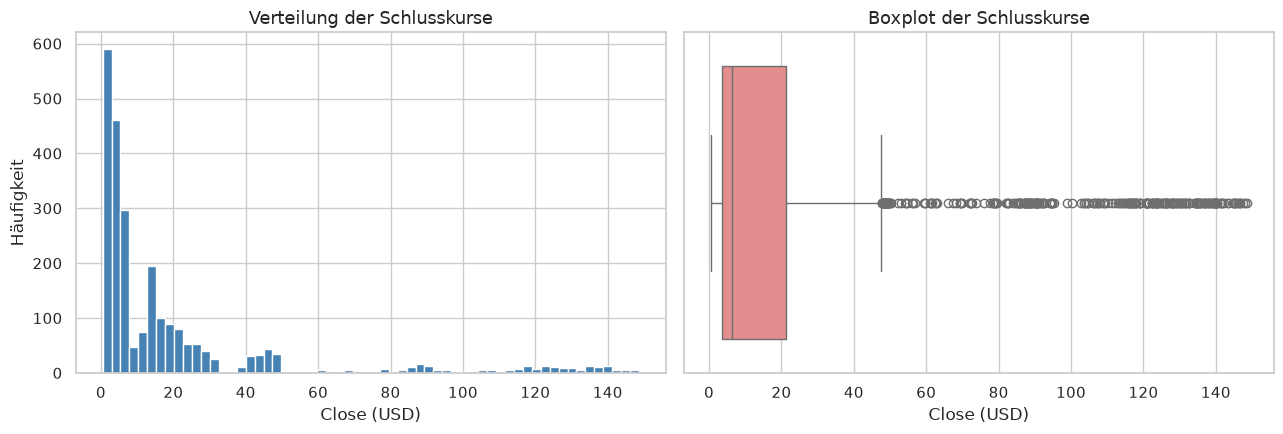

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["Close"], bins=60, color="steelblue", edgecolor="white")
axes[0].set(title="Verteilung der Schlusskurse", xlabel="Close (USD)", ylabel="Häufigkeit")
sns.boxplot(x=df["Close"], ax=axes[1], color="lightcoral")
axes[1].set(title="Boxplot der Schlusskurse", xlabel="Close (USD)")
plt.tight_layout(); plt.show()

Die Kursverteilung ist **stark rechtsschief** (positive Schiefe): Das Kursniveau
ist über den Zeitraum massiv gestiegen, sodass viele niedrige „frühe" Kurse und
wenige sehr hohe „späte" Kurse vorliegen. Das ist ein erstes Indiz für einen
ausgeprägten **Trend** und damit für **Nicht-Stationarität** des Kurslevels –
ein zentraler Punkt für die spätere Modellierung.

### 4.2  Rendite- und Preisanalysen

Da das *Kursniveau* nicht-stationär ist, betrachten wir zusätzlich die
**Renditen** (relative Änderungen). Wir verwenden log-Renditen
$r_t = \ln(P_t / P_{t-1})$, da sie zeitlich additiv und besser handhabbar sind.

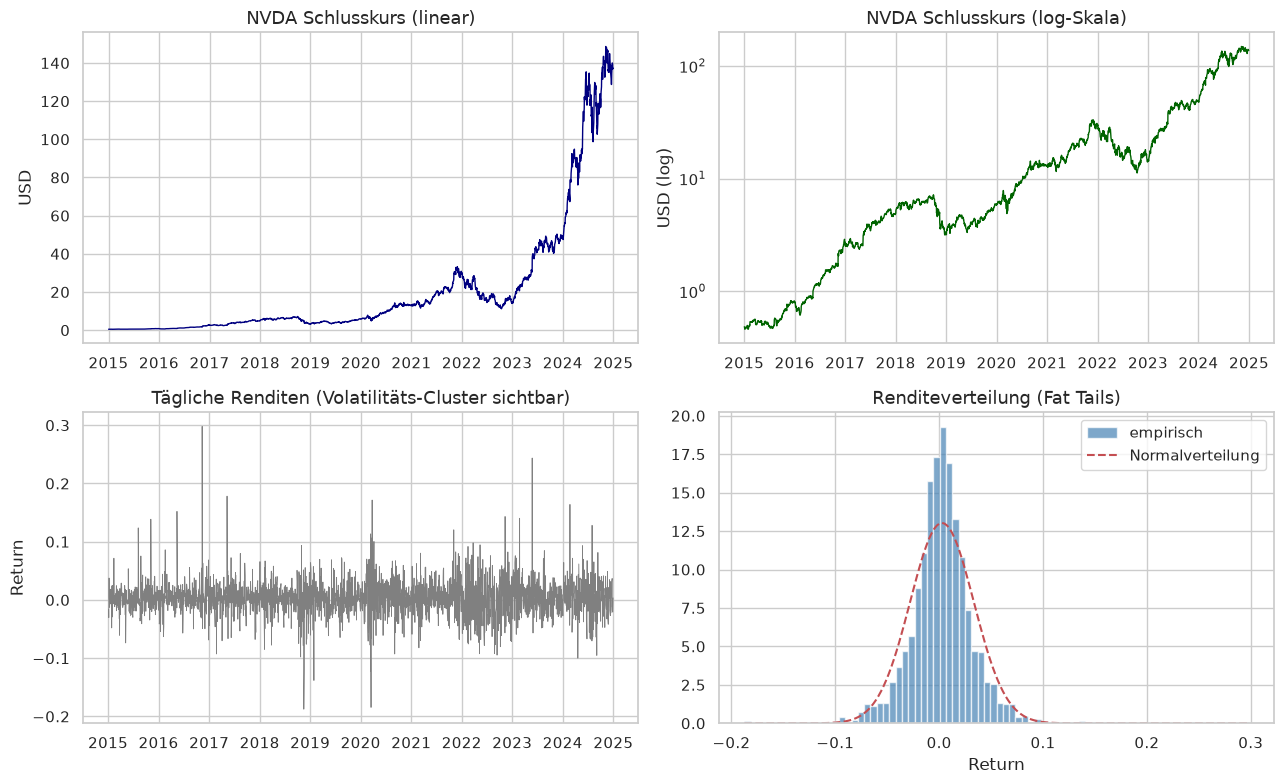

Mittlere Tagesrendite : 0.2714%
Tagesvolatilität      : 3.0621%
Annualisierte Vola    : 48.61%
Schiefe / Kurtosis    : 0.63 / 8.32  (Normal: 0 / 0)
Jarque-Bera-Test      : Statistik=7381.9, p=0 -> Normalvert. verworfen


In [8]:
df["Return"]    = df["Close"].pct_change()
df["LogReturn"] = np.log(df["Close"]).diff()
df["Weekly"]    = df["Close"].resample("W").last().pct_change().reindex(df.index, method="ffill")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
# Kursverlauf (log-Skala macht den exponentiellen Trend sichtbar)
axes[0,0].plot(df.index, df["Close"], color="navy", lw=1)
axes[0,0].set(title="NVDA Schlusskurs (linear)", ylabel="USD")
axes[0,1].semilogy(df.index, df["Close"], color="darkgreen", lw=1)
axes[0,1].set(title="NVDA Schlusskurs (log-Skala)", ylabel="USD (log)")
# Tagesrenditen
axes[1,0].plot(df.index, df["Return"], color="gray", lw=0.6)
axes[1,0].set(title="Tägliche Renditen (Volatilitäts-Cluster sichtbar)", ylabel="Return")
# Renditeverteilung vs. Normalverteilung
r = df["Return"].dropna()
axes[1,1].hist(r, bins=80, density=True, color="steelblue", alpha=0.7, label="empirisch")
x = np.linspace(r.min(), r.max(), 200)
axes[1,1].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", label="Normalverteilung")
axes[1,1].set(title="Renditeverteilung (Fat Tails)", xlabel="Return"); axes[1,1].legend()
plt.tight_layout(); plt.show()

print(f"Mittlere Tagesrendite : {r.mean():.4%}")
print(f"Tagesvolatilität      : {r.std():.4%}")
print(f"Annualisierte Vola    : {r.std()*np.sqrt(252):.2%}")
print(f"Schiefe / Kurtosis    : {r.skew():.2f} / {r.kurt():.2f}  (Normal: 0 / 0)")
jb = stats.jarque_bera(r)
print(f"Jarque-Bera-Test      : Statistik={jb[0]:.1f}, p={jb[1]:.3g} -> Normalvert. {'verworfen' if jb[1]<0.05 else 'nicht verworfen'}")

Die Renditen sind annähernd mittelwertfrei, weisen aber **deutlich schwerere
Ränder** (positive Exzess-Kurtosis, „Fat Tails") als die Normalverteilung auf –
ein für Finanzzeitreihen typisches Stilfaktum. Außerdem sind in den Tagesrenditen
**Volatilitäts-Cluster** erkennbar (ruhige und turbulente Phasen wechseln sich
ab). Beides spricht gegen einfache lineare/normalverteilungsbasierte Annahmen.

### 4.3  Analyse zeitlicher Strukturen und Stationaritätsprüfung (ADF + KPSS)

Wir untersuchen Trend, Wochentagseffekte, Autokorrelation und prüfen die
**Stationarität** mit zwei komplementären Tests:

| Test | H₀ | Verwurf bei p < 0.05 |
|---|---|---|
| **ADF** (Augmented Dickey-Fuller) | Einheitswurzel (nicht-stationär) | → stationär |
| **KPSS** (Kwiatkowski-Phillips-Schmidt-Shin) | stationär | → nicht-stationär |

Da beide Tests **umgekehrte Nullhypothesen** haben, gelten erst dann robuste Aussagen,
wenn **beide Tests übereinstimmen**: ADF verwirft H₀ *und* KPSS verwirft H₀ nicht
→ Stationarität doppelt bestätigt.

In [9]:
stationarity_results = {}   # name -> dict(adf_stat, adf_p, kpss_stat, kpss_p, verdict)

def adf_report(series, name):
    s = series.dropna()
    res = adfuller(s, autolag="AIC")
    print(f"--- ADF-Test: {name} ---")
    print(f"  Teststatistik : {res[0]:.4f}")
    print(f"  p-Wert        : {res[1]:.4g}")
    print(f"  krit. Werte   : " + ", ".join(f"{k}={v:.2f}" for k, v in res[4].items()))
    verdict = "STATIONÄR (H0 verworfen)" if res[1] < 0.05 else "NICHT stationär (H0 nicht verworfen)"
    print(f"  => {verdict}\n")
    return res[0], res[1]

def kpss_report(series, name, regression="c"):
    s = series.dropna()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, crit = kpss(s, regression=regression, nlags="auto")
    print(f"--- KPSS-Test: {name} (regression='{regression}') ---")
    print(f"  Teststatistik : {stat:.4f}")
    print(f"  p-Wert        : {p:.4g}")
    print(f"  krit. Werte   : " + ", ".join(f"{k}={v:.3f}" for k, v in crit.items()))
    verdict = "NICHT stationär (H0 verworfen)" if p < 0.05 else "STATIONÄR (H0 nicht verworfen)"
    print(f"  => {verdict}\n")
    return stat, p

def combined_verdict(adf_p, kpss_p, name):
    adf_stat  = adf_p  < 0.05   # True = verworfen = stationär-Signal
    kpss_stat = kpss_p >= 0.05  # True = nicht verworfen = stationär-Signal
    if adf_stat and kpss_stat:
        v = "STATIONÄR  (beide Tests übereinstimmend)"
    elif not adf_stat and not kpss_stat:
        v = "NICHT STATIONÄR  (beide Tests übereinstimmend)"
    elif adf_stat and not kpss_stat:
        v = "TRENDDSTATIONÄR? (ADF: stationär, KPSS: nicht stationär — Differenzierung prüfen)"
    else:
        v = "UNSCHLÜSSIG  (ADF: nicht stationär, KPSS: stationär — mehr Daten nötig)"
    print(f"==> Kombiniertes Urteil [{name}]: {v}\n")
    return v

def run_stationarity_tests(series, name):
    adf_stat, adf_p   = adf_report(series, name)
    kpss_stat, kpss_p = kpss_report(series, name)
    verdict = combined_verdict(adf_p, kpss_p, name)
    stationarity_results[name] = {
        "ADF_stat": adf_stat, "ADF_p": adf_p,
        "KPSS_stat": kpss_stat, "KPSS_p": kpss_p, "Verdict": verdict,
    }

run_stationarity_tests(df["Close"],      "Close (Niveau)")
run_stationarity_tests(df["Return"],     "Einfache Renditen")
run_stationarity_tests(df["LogReturn"],  "Log-Renditen")

--- ADF-Test: Close (Niveau) ---
  Teststatistik : 3.1575
  p-Wert        : 1
  krit. Werte   : 1%=-3.43, 5%=-2.86, 10%=-2.57
  => NICHT stationär (H0 nicht verworfen)

--- KPSS-Test: Close (Niveau) (regression='c') ---
  Teststatistik : 4.5229
  p-Wert        : 0.01
  krit. Werte   : 10%=0.347, 5%=0.463, 2.5%=0.574, 1%=0.739
  => NICHT stationär (H0 verworfen)

==> Kombiniertes Urteil [Close (Niveau)]: NICHT STATIONÄR  (beide Tests übereinstimmend)

--- ADF-Test: Einfache Renditen ---
  Teststatistik : -16.2949
  p-Wert        : 3.31e-29
  krit. Werte   : 1%=-3.43, 5%=-2.86, 10%=-2.57
  => STATIONÄR (H0 verworfen)

--- KPSS-Test: Einfache Renditen (regression='c') ---
  Teststatistik : 0.0795
  p-Wert        : 0.1
  krit. Werte   : 10%=0.347, 5%=0.463, 2.5%=0.574, 1%=0.739
  => STATIONÄR (H0 nicht verworfen)

==> Kombiniertes Urteil [Einfache Renditen]: STATIONÄR  (beide Tests übereinstimmend)

--- ADF-Test: Log-Renditen ---
  Teststatistik : -16.2695
  p-Wert        : 3.5e-29
  krit.

**Interpretation.** Wie erwartet zeigen beide Tests übereinstimmend:

* **Kurslevel:** ADF verwirft H₀ nicht, KPSS verwirft H₀ → **nicht-stationär**.
  Das Kurslevel verhält sich wie ein integrierter Prozess erster Ordnung $I(1)$.
* **Tagesrendite:** ADF verwirft H₀, KPSS verwirft H₀ nicht → **stationär**.
  Durch einfache Differenzierung (Log-Rendite) erreichen wir Stationarität.

**Konsequenz für die Modellierung:** Ein Modell auf dem rohen Kurslevel „lernt"
leicht den Trend bzw. den Vortageswert nach. Die kombinierten Tests bestätigen,
dass nur Log-Renditen eine stationäre, modellierfähige Basis darstellen.

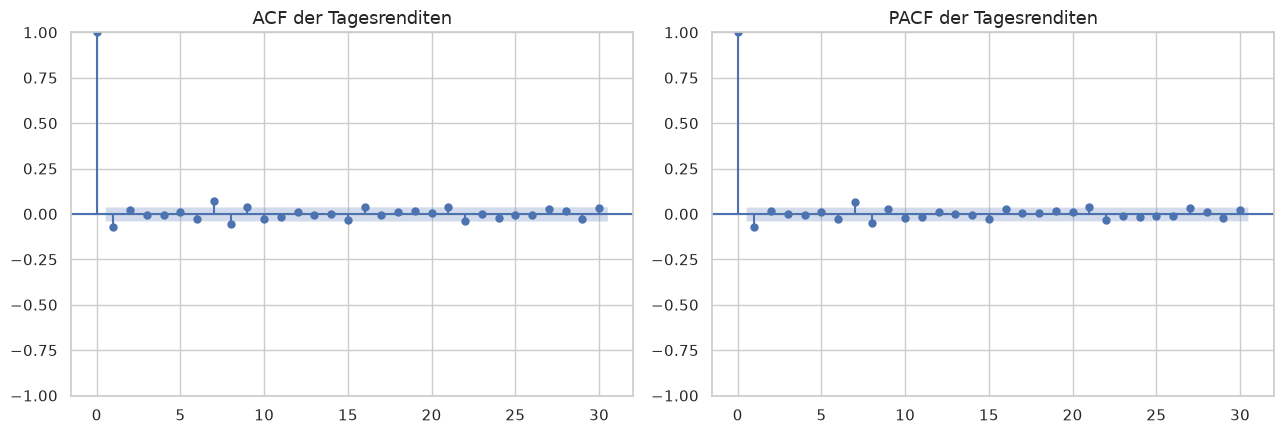

Durchschnittliche Rendite je Wochentag:
             mean    std  count
Montag     0.0034 0.0309    469
Dienstag   0.0028 0.0278    517
Mittwoch   0.0024 0.0286    515
Donnerstag 0.0037 0.0326    509
Freitag    0.0013 0.0330    504


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_acf(df["Return"].dropna(), lags=30, ax=axes[0], title="ACF der Tagesrenditen")
plot_pacf(df["Return"].dropna(), lags=30, ax=axes[1], title="PACF der Tagesrenditen", method="ywm")
plt.tight_layout(); plt.show()

# Wochentagseffekte
df["Weekday"] = df.index.dayofweek  # 0=Mo ... 4=Fr
wd_names = ["Montag", "Dienstag", "Mittwoch", "Donnerstag", "Freitag"]
wd = df.groupby("Weekday")["Return"].agg(["mean", "std", "count"])
wd.index = [wd_names[i] for i in wd.index]
print("Durchschnittliche Rendite je Wochentag:")
print(wd)

Die Autokorrelation der **Renditen** ist über praktisch alle Lags sehr gering –
ein weiteres Indiz dafür, dass künftige Renditen aus vergangenen Renditen kaum
linear vorhersagbar sind (Markteffizienz in schwacher Form). Etwaige
Wochentagseffekte sind klein und ökonomisch wenig bedeutsam. **Das Kurslevel**
hingegen ist hochgradig autokorreliert (nahezu 1 bei Lag 1), was genau der
naiven „morgen = heute"-Struktur entspricht.

### 4.4  Volumen-, Liquiditäts- und Korrelationsanalysen

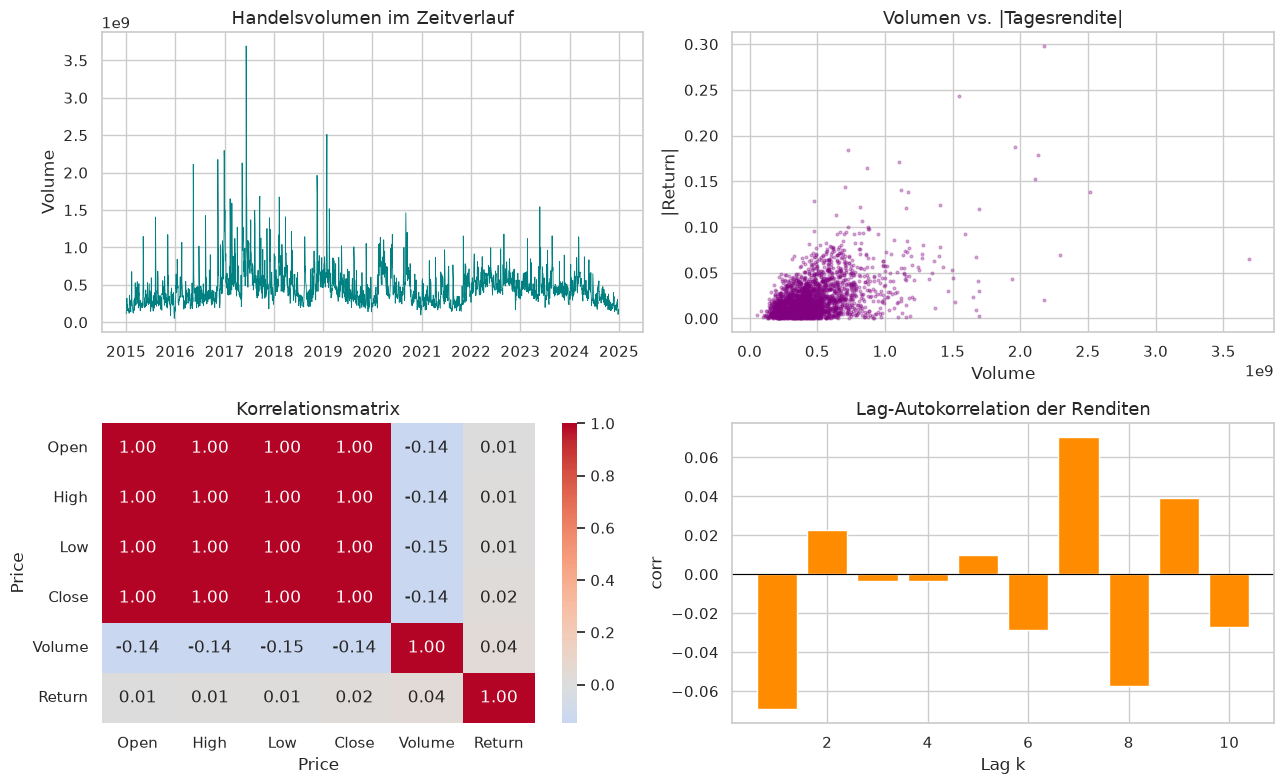

Korrelation Volumen vs. |Rendite|: 0.510


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0,0].plot(df.index, df["Volume"], color="teal", lw=0.6)
axes[0,0].set(title="Handelsvolumen im Zeitverlauf", ylabel="Volume")
# Volumen vs. absolute Rendite
axes[0,1].scatter(df["Volume"], df["Return"].abs(), s=4, alpha=0.3, color="purple")
axes[0,1].set(title="Volumen vs. |Tagesrendite|", xlabel="Volume", ylabel="|Return|")
# Korrelationsmatrix
corr_cols = ["Open", "High", "Low", "Close", "Volume", "Return"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[1,0])
axes[1,0].set(title="Korrelationsmatrix")
# Lag-Korrelation: Rendite_t vs. Rendite_{t-k}
lags = range(1, 11)
lagcorr = [df["Return"].corr(df["Return"].shift(k)) for k in lags]
axes[1,1].bar(list(lags), lagcorr, color="darkorange")
axes[1,1].axhline(0, color="black", lw=0.8)
axes[1,1].set(title="Lag-Autokorrelation der Renditen", xlabel="Lag k", ylabel="corr")
plt.tight_layout(); plt.show()

print(f"Korrelation Volumen vs. |Rendite|: {df['Volume'].corr(df['Return'].abs()):.3f}")

Das Handelsvolumen korreliert **positiv mit der Stärke der Kursbewegungen**
(höheres Volumen an turbulenten Tagen) – ein bekannter Zusammenhang zwischen
Liquidität/Aufmerksamkeit und Volatilität. Die OHLC-Variablen sind erwartungsgemäß
untereinander nahezu perfekt korreliert (sie beschreiben denselben Tag). Die
Lag-Autokorrelation der Renditen ist gering, bestätigt also den Befund aus 4.3.

**Ergänzung: Korrelation auf Basis von Log-Renditen.** Die OHLC-Rohpreise
korrelieren fast perfekt untereinander, weil sie vom selben Kursniveau dominiert
werden (Scheinkorrelation). Aussagekräftiger ist die Korrelationsstruktur der
*täglichen Log-Renditen* mit Volatilität und Volumen, da das gemeinsame
Kursniveau hier herausgerechnet ist.


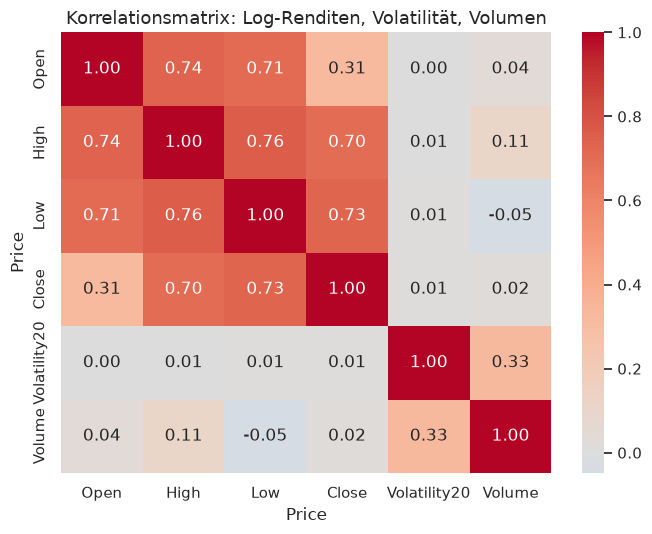

In [12]:
log_rets = np.log(df[["Open", "High", "Low", "Close"]]).diff()
log_rets["Volatility20"] = df["LogReturn"].rolling(20).std()
log_rets["Volume"] = df["Volume"]
log_rets = log_rets.dropna()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(log_rets.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set(title="Korrelationsmatrix: Log-Renditen, Volatilität, Volumen")
plt.tight_layout(); plt.show()


### 4.5  Analyse ausgewählter markt- und unternehmensbezogener Ereignisse

Wir identifizieren die stärksten Tagesbewegungen und ordnen auffällige
Kursphasen ein. Bei echten Daten lassen sich diese häufig mit konkreten
Ereignissen (Quartalszahlen, Produktankündigungen, Makro-Schocks wie dem
COVID-Crash im März 2020 oder dem KI-Boom ab 2023) in Verbindung bringen.

Top-10 Tage mit den stärksten Kursbewegungen:
Price        Close  Return      Volume
Date                                  
2016-05-13  1.0020  0.1521  2110256000
2016-11-11  2.1606  0.2981  2175344000
2017-05-10  2.9871  0.1783  2129096000
2018-11-16  4.0675 -0.1876  1963520000
2020-03-16  4.8851 -0.1845   726972000
2020-03-24  6.1979  0.1716  1101644000
2022-11-10 15.7111  0.1433   700819000
2023-02-23 23.6115  0.1402  1117995000
2023-05-25 37.9022  0.2437  1543911000
2024-02-22 78.3987  0.1640   865100000


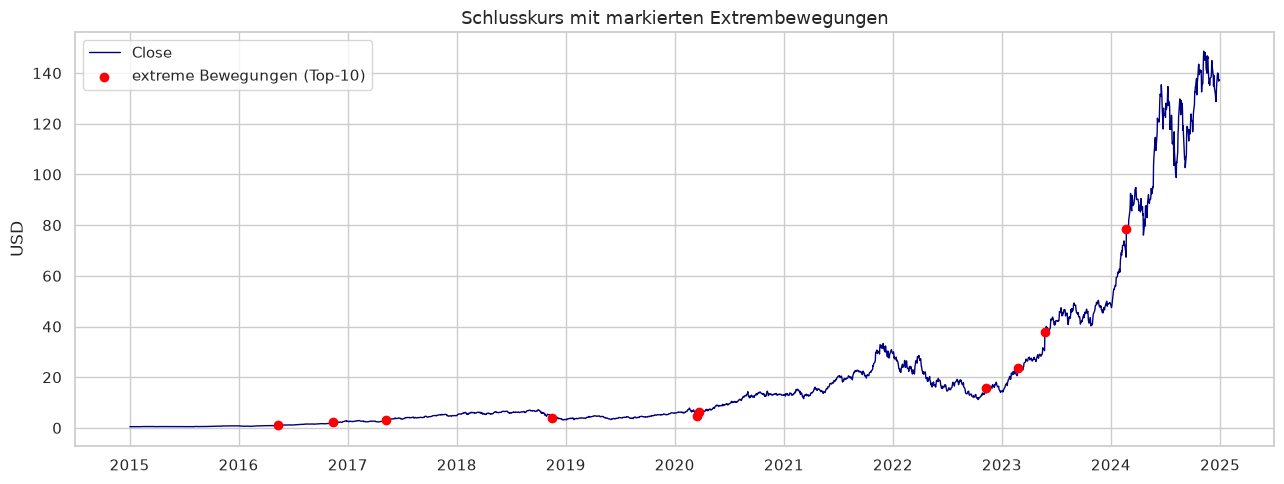

In [13]:
extreme = df["Return"].dropna().abs().sort_values(ascending=False).head(10)
events = df.loc[extreme.index, ["Close", "Return", "Volume"]].sort_index()
print("Top-10 Tage mit den stärksten Kursbewegungen:")
print(events)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["Close"], color="navy", lw=1, label="Close")
ax.scatter(extreme.index, df.loc[extreme.index, "Close"],
           color="red", zorder=5, label="extreme Bewegungen (Top-10)")
ax.set(title="Schlusskurs mit markierten Extrembewegungen", ylabel="USD")
ax.legend(); plt.tight_layout(); plt.show()

> **Hinweis:** Bei Verwendung des synthetischen Fallback-Datensatzes haben diese
> „Ereignisse" naturgemäß keine reale Entsprechung; sie illustrieren lediglich
> die Methodik. Mit echten Yahoo-Finance-Daten sollten die markierten Tage gegen
> einen Ereigniskalender (Earnings, GTC-Keynotes, Makro-Ereignisse) abgeglichen
> werden.

## 5  Datenvorverarbeitung und Feature Engineering

Aufbauend auf der EDA bereiten wir die Daten für die Modellierung vor.

### 5.1  Ableitung zusätzlicher Merkmale (inkl. technische Indikatoren)

Wir erzeugen aus den Rohdaten interpretierbare Merkmale, die typische
Eigenschaften von Finanzzeitreihen abbilden. Neben den grundlegenden Features
ergänzen wir drei klassische **technische Indikatoren**, die in der Praxis
häufig für Handelssignale genutzt werden:

| Feature | Beschreibung | Formel / Quelle |
|---|---|---|
| **LogReturn** | Stationäre Tagesrendite | $\ln(P_t/P_{t-1})$ |
| **MA20 / MA50** | Gleitende Durchschnitte | 20-/50-Tage-SMA |
| **MA_Ratio** | Relative Lage zum Kurzfristtrend | $P_t / \text{MA20}$ |
| **Volatility20** | Rollierende Volatilität | Std der Log-Renditen (20 T) |
| **Volume_z** | Volumen z-standardisiert | rollierendes z-Score |
| **Weekday** | Wochentag (0=Mo … 4=Fr) | `dayofweek` |
| **RSI14** | Relative Strength Index | $100 - 100/(1+\bar{g}_{14}/\bar{l}_{14})$ |
| **MACD** | MACD-Linie | EMA(12) $-$ EMA(26) |
| **BB_Pct** | Bollinger-Band-Position | $(P - \text{BB}_{low}) / (\text{BB}_{up} - \text{BB}_{low})$ |

> **Technische Indikatoren** kodieren Momentum (RSI), Trenddynamik (MACD) und
> relative Preislage (Bollinger %B). Sie stellen keine garantierten Prädiktoren
> dar – die EDA-Erkenntnisse (nahezu unkorrelierte Renditen, Random-Walk-Charakter)
> gelten weiterhin. Der Mehrwert wird quantitativ durch den Modellvergleich
> bewertet.

Durch rollierende Fenster entstehen am Reihenanfang `NaN`-Werte, die wir
systematisch entfernen.

In [14]:
feat = df.copy()

# --- Basisfeatures -----------------------------------------------------------
feat["MA20"]         = feat["Close"].rolling(20).mean()
feat["MA50"]         = feat["Close"].rolling(50).mean()
feat["MA_Ratio"]     = feat["Close"] / feat["MA20"]
feat["Volatility20"] = feat["LogReturn"].rolling(20).std()
feat["Volume_z"]     = ((feat["Volume"] - feat["Volume"].rolling(20).mean())
                        / feat["Volume"].rolling(20).std())
feat["Weekday"]      = feat.index.dayofweek

# --- RSI 14 (Relative Strength Index) ----------------------------------------
_delta = feat["Close"].diff()
_gain  = _delta.clip(lower=0).rolling(14).mean()
_loss  = (-_delta.clip(upper=0)).rolling(14).mean()
feat["RSI14"] = 100 - 100 / (1 + _gain / (_loss + 1e-8))

# --- MACD (EMA12 − EMA26) ----------------------------------------------------
_ema12 = feat["Close"].ewm(span=12, adjust=False).mean()
_ema26 = feat["Close"].ewm(span=26, adjust=False).mean()
feat["MACD"] = _ema12 - _ema26

# --- Bollinger Bands %B (Position innerhalb der Bänder) ----------------------
_bb_std   = feat["Close"].rolling(20).std()
_bb_upper = feat["MA20"] + 2 * _bb_std
_bb_lower = feat["MA20"] - 2 * _bb_std
feat["BB_Pct"] = (feat["Close"] - _bb_lower) / (_bb_upper - _bb_lower + 1e-8)

# --- NaN-Bereinigung & Überblick ---------------------------------------------
feat = feat.dropna(subset=FEATURES).copy()
print(f"Beobachtungen nach Feature-Engineering: {len(feat):,}")
print(f"Eingangsmerkmale ({len(FEATURES)}): {FEATURES}")
feat[FEATURES].describe().T[["mean", "std", "min", "max"]]

Beobachtungen nach Feature-Engineering: 2,495
Eingangsmerkmale (9): ['Close', 'LogReturn', 'MA_Ratio', 'Volatility20', 'Volume_z', 'Weekday', 'RSI14', 'MACD', 'BB_Pct']


,mean,std,min,max
Price,,,,
Close,20.8764,32.2762,0.4667,148.6478
LogReturn,0.0023,0.0304,-0.2077,0.2609
MA_Ratio,1.0229,0.0732,0.7226,1.3012
Volatility20,0.0280,0.0120,0.0090,0.0880
Volume_z,-0.0140,1.0714,-2.7421,4.0724
Weekday,2.0240,1.3989,0.0000,4.0000
RSI14,56.9386,17.1737,8.1879,99.4287
MACD,0.3852,1.3189,-5.1594,9.7601
BB_Pct,0.6094,0.3194,-0.3870,1.4622


**Visualisierung der technischen Indikatoren.** Die folgenden Plots zeigen RSI,
MACD und Bollinger Bands im Zeitverlauf. Typische Handelssignale (z. B. RSI > 70
als Überkauft-Zone oder RSI < 30 als Überverkauft-Zone, MACD-Kreuzungen mit der
Nulllinie) sind erkennbar – sie stellen hypothetische Eingangssignale für das
Modell dar.

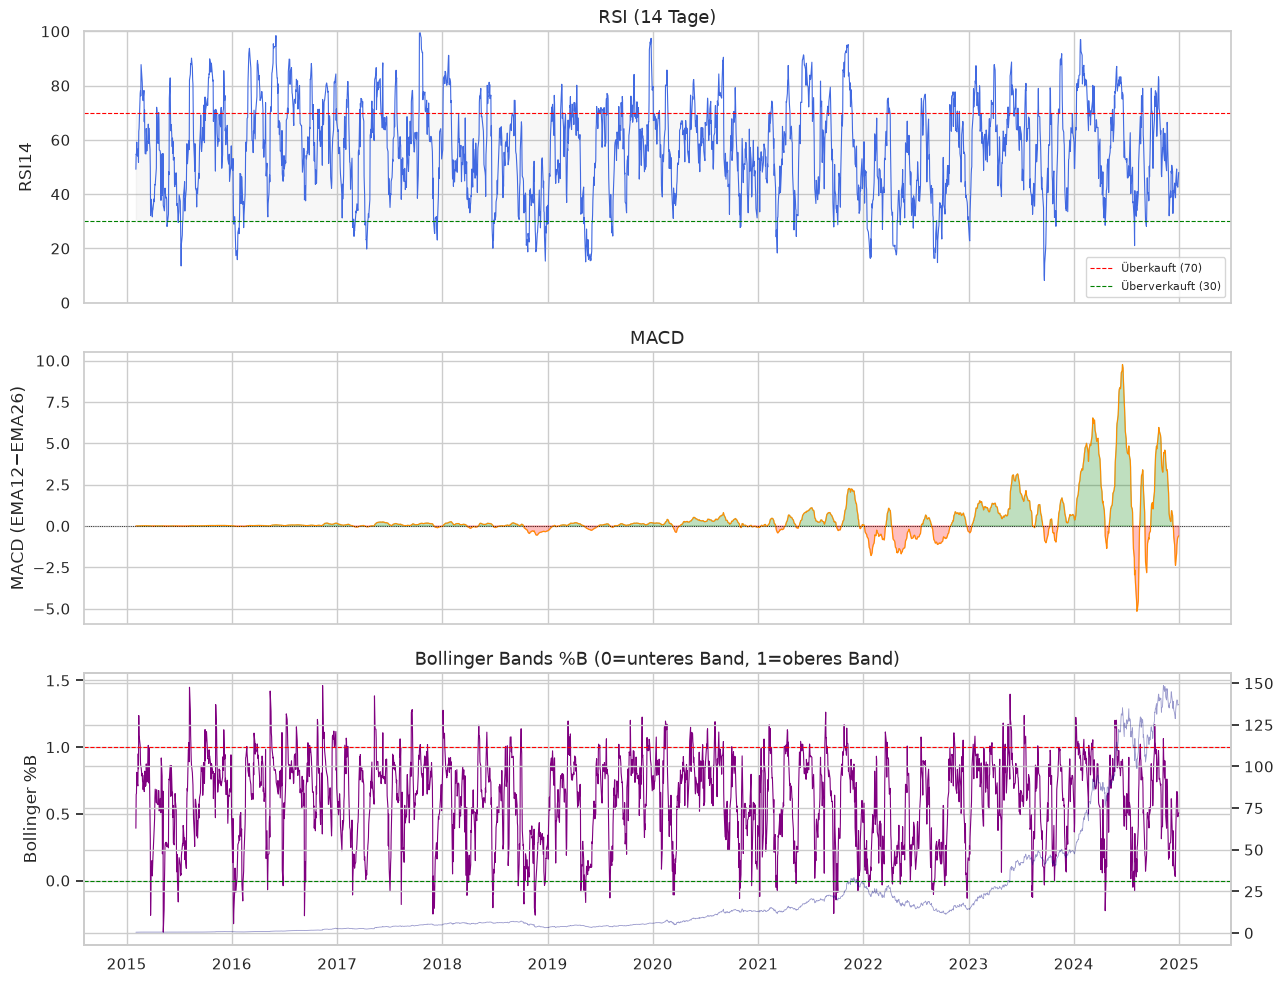

RSI14   – Min/Max: 8.2 / 99.4
MACD    – Std:     1.319
BB_Pct  – Anteil > 1 (Überschreitung):  8.1%
BB_Pct  – Anteil < 0 (Unterschreitung): 3.6%


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# RSI
axes[0].plot(feat.index, feat["RSI14"], color="royalblue", lw=0.8)
axes[0].axhline(70, color="red",   ls="--", lw=0.8, label="Überkauft (70)")
axes[0].axhline(30, color="green", ls="--", lw=0.8, label="Überverkauft (30)")
axes[0].fill_between(feat.index, 30, 70, alpha=0.06, color="gray")
axes[0].set(ylabel="RSI14", ylim=(0, 100))
axes[0].legend(fontsize=8)
axes[0].set_title("RSI (14 Tage)")

# MACD + Nulllinie
axes[1].plot(feat.index, feat["MACD"], color="darkorange", lw=0.8, label="MACD")
axes[1].axhline(0, color="black", lw=0.6, ls=":")
axes[1].fill_between(feat.index, feat["MACD"], 0,
                     where=feat["MACD"] >= 0, alpha=0.25, color="green")
axes[1].fill_between(feat.index, feat["MACD"], 0,
                     where=feat["MACD"] < 0,  alpha=0.25, color="red")
axes[1].set(ylabel="MACD (EMA12−EMA26)")
axes[1].set_title("MACD")

# Bollinger %B + Preiskurs
ax2b = axes[2].twinx()
ax2b.plot(feat.index, feat["Close"], color="navy", lw=0.6, alpha=0.4, label="Close")
axes[2].plot(feat.index, feat["BB_Pct"], color="purple", lw=0.8, label="BB %B")
axes[2].axhline(1.0, color="red",   ls="--", lw=0.8)
axes[2].axhline(0.0, color="green", ls="--", lw=0.8)
axes[2].set(ylabel="Bollinger %B")
axes[2].set_title("Bollinger Bands %B (0=unteres Band, 1=oberes Band)")

plt.tight_layout(); plt.show()
print(f"RSI14   – Min/Max: {feat['RSI14'].min():.1f} / {feat['RSI14'].max():.1f}")
print(f"MACD    – Std:     {feat['MACD'].std():.3f}")
print(f"BB_Pct  – Anteil > 1 (Überschreitung):  {(feat['BB_Pct']>1).mean():.1%}")
print(f"BB_Pct  – Anteil < 0 (Unterschreitung): {(feat['BB_Pct']<0).mean():.1%}")

### 5.2  Skalierung, Sliding-Window und zeitlicher Split

**Wichtig (Vermeidung von Look-Ahead-Bias):**

1. Die Aufteilung in **Trainings-, Validierungs- und Testdaten** erfolgt *streng
   chronologisch* (70 % / 15 % / 15 %) – niemals zufällig, da sonst Zukunft in
   die Vergangenheit „durchsickern" würde.
2. Der `MinMaxScaler` wird **ausschließlich auf den Trainingsdaten** gefittet und
   erst danach auf alle Daten angewendet.
3. Mit einem **Sliding-Window-Ansatz** überführen wir die Zeitreihe in ein
   überwachtes Lernproblem: Die letzten `WINDOW = 60` Handelstage (alle Merkmale)
   dienen als Eingabe $X$, der Schlusskurs des **Folgetages** als Ziel $y$.

In [16]:
n = len(feat)
i_train = int(n * SPLIT_TRAIN)
i_val   = int(n * SPLIT_VAL)
print(f"Split-Grenzen (chronologisch): Train < {i_train} | Val < {i_val} | Test < {n}")
print(f"  Train bis {feat.index[i_train-1].date()}, "
      f"Val bis {feat.index[i_val-1].date()}, Test bis {feat.index[-1].date()}")

# Scaler NUR auf Trainingsdaten fitten (kein Leakage)
feat_scaler  = MinMaxScaler().fit(feat[FEATURES].iloc[:i_train])
close_scaler = MinMaxScaler().fit(feat[[TARGET]].iloc[:i_train])

X_all     = feat_scaler.transform(feat[FEATURES])
close_all = close_scaler.transform(feat[[TARGET]]).ravel()

# Sliding-Window aufbauen; Zuordnung der Fenster zu Split anhand des Zielindex i
def build_windows(lo, hi):
    Xs, ys, idx = [], [], []
    start = max(lo, WINDOW)
    for i in range(start, hi):
        Xs.append(X_all[i-WINDOW:i])
        ys.append(close_all[i])
        idx.append(i)
    return np.array(Xs), np.array(ys), np.array(idx)

X_train, y_train, idx_train = build_windows(0,        i_train)
X_val,   y_val,   idx_val   = build_windows(i_train,  i_val)
X_test,  y_test,  idx_test  = build_windows(i_val,    n)

print(f"\nX_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"(Fenstergröße={WINDOW}, Merkmale={len(FEATURES)})")

Split-Grenzen (chronologisch): Train < 1746 | Val < 2120 | Test < 2495
  Train bis 2022-01-05, Val bis 2023-07-05, Test bis 2024-12-30

X_train: (1686, 60, 9)  X_val: (374, 60, 9)  X_test: (375, 60, 9)
(Fenstergröße=60, Merkmale=9)


## 6  Modellierung und Training

### 6.1  Referenzmodelle (Baselines)

Den Baselines kommt eine zentrale Rolle zu: In der Kursprognose ist bereits die
**naive Fortschreibung** des letzten Wertes ein überraschend starkes Modell.
Wir definieren zwei Referenzverfahren – jeweils im **Preisraum** (USD), damit sie
direkt mit den (rücktransformierten) LSTM-Prognosen vergleichbar sind:

* **Naive Prognose:** $\hat{P}_{t} = P_{t-1}$ („morgen entspricht heute").
* **Moving-Average-Prognose:** $\hat{P}_{t} = \text{MA20}_{t-1}$.

In [17]:
# Tatsächliche Preise an den Test-Zielindizes
y_test_price = feat[TARGET].values[idx_test]
# Naive Prognose: Schlusskurs des Vortages (= letzter Tag im Eingabefenster)
naive_pred   = feat[TARGET].values[idx_test - 1]
# MA-Prognose: MA20 des Vortages
ma_pred      = feat["MA20"].values[idx_test - 1]

def metrics(y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    mape  = mean_absolute_percentage_error(y_true, y_pred)
    smape = float(np.mean(2 * np.abs(y_true - y_pred)
                          / (np.abs(y_true) + np.abs(y_pred) + 1e-8)))
    return mae, mse, rmse, r2, mape, smape

results = {}
results["Naiv (P_{t-1})"]      = metrics(y_test_price, naive_pred)
results["Moving Average (MA20)"] = metrics(y_test_price, ma_pred)
for name, (mae, mse, rmse, r2, mape, smape) in results.items():
    print(f"{name:24s}  MAE={mae:8.3f}  RMSE={rmse:8.3f}  "
          f"R²={r2:+.4f}  MAPE={mape:.2%}  sMAPE={smape:.2%}")

Naiv (P_{t-1})            MAE=   2.029  RMSE=   2.927  R²=+0.9936  MAPE=2.24%  sMAPE=2.25%
Moving Average (MA20)     MAE=   5.645  RMSE=   7.539  R²=+0.9575  MAPE=6.36%  sMAPE=6.53%


### 6.2  Klassisches Zeitreihenmodell mit automatischer Ordnungswahl (ARIMA/SARIMA)

Als statistischen Benchmark zwischen den naiven Baselines und dem LSTM setzen wir
ein **ARIMA/SARIMA-Modell** ein. Statt die Ordnung $(p,d,q)\,(P,D,Q)_m$ von Hand
festzulegen, lassen wir das Modell sich **selbst optimieren**: Eine
**AIC-Gittersuche** (das Prinzip von *Auto-ARIMA*) probiert systematisch
verschiedene Ordnungen aus und wählt jene mit dem niedrigsten
**Akaike-Informationskriterium (AIC)** – also den besten Kompromiss aus
Modellgüte und Sparsamkeit.

Methodische Eckpunkte:

* Modelliert wird der **log-transformierte Schlusskurs** (stabilisiert die
  Varianz). Die Differenzierungsordnung $d$ wird **mitgesucht** ($d \in \{1, 2\}$)
  und trägt der in Kap. 4.3 festgestellten Nicht-Stationarität Rechnung.
* **Erweiterte, zweistufige Suche** (zur Begrenzung der Rechenzeit):
  *Stufe 1* durchsucht ein großes **nicht-saisonales** Gitter
  $p \in \{0,\dots,4\}$, $d \in \{1,2\}$, $q \in \{0,\dots,4\}$;
  *Stufe 2* verfeinert die beste gefundene Ordnung um eine **saisonale
  Komponente** mit Periode $m=5$ (Handelswoche) – daher *S*ARIMA.
* Die Ordnungswahl erfolgt auf **Trainings + Validierungsdaten**; die Bewertung
  auf der Testmenge geschieht per **Walk-Forward-Prognose** (1-Schritt voraus):
  Die Modellparameter werden eingefroren, und nach jedem Schritt wird der *echte*
  beobachtete Wert angehängt (`append`, kein Neufit) – das vermeidet
  Look-Ahead-Bias und ist direkt mit Naiv/MA/LSTM vergleichbar.

> *Hinweis:* Ist das optionale Paket `pmdarima` installiert, könnte man dessen
> `auto_arima` nutzen; um Abhängigkeiten gering zu halten, implementieren wir die
> Auto-Auswahl hier eigenständig mit `statsmodels`.

In [18]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Zielreihe als log-Preis (Varianzstabilisierung); Order-Wahl auf Train+Val
log_close = np.log(feat[TARGET].values.astype(float))
split_idx = int(idx_test[0])          # erster Test-Zielindex (= i_val)
y_fit     = log_close[:split_idx]

def fit_sarimax(order, seasonal):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")            # Konvergenzwarnungen unterdrücken
        return SARIMAX(y_fit, order=order, seasonal_order=seasonal,
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=0)

def try_fit(order, seasonal, store, best):
    # Fittet ein Modell, protokolliert AIC und aktualisiert das beste Modell
    try:
        res = fit_sarimax(order, seasonal)
        store.append({"order": order, "seasonal": seasonal, "AIC": res.aic})
        if res.aic < best["aic"]:
            best.update({"aic": res.aic, "order": order, "seasonal": seasonal})
    except Exception:
        pass

aic_rows, best = [], {"aic": np.inf, "order": (1, 1, 0), "seasonal": (0, 0, 0, 0)}

# Stufe 1: großes nicht-saisonales Gitter
_cands_s1 = [(p, d, q) for p, d, q
             in itertools.product(ARIMA_P_RANGE, ARIMA_D_RANGE, ARIMA_Q_RANGE)
             if not (p == 0 and q == 0)]
for (p, d, q) in tqdm(_cands_s1, desc="ARIMA Stufe 1 (nicht-saisonal)", unit="Kandidat"):
    try_fit((p, d, q), (0, 0, 0, 0), aic_rows, best)
n_stage1 = len(aic_rows)

# Stufe 2: saisonale Verfeinerung um die beste nicht-saisonale Ordnung
base_order = best["order"]
for so in tqdm(ARIMA_SEASONAL_CANDIDATES, desc="ARIMA Stufe 2 (saisonal)", unit="Kandidat"):
    try_fit(base_order, so, aic_rows, best)

aic_df = pd.DataFrame(aic_rows).sort_values("AIC").reset_index(drop=True)
print(f"Durchsuchte Kandidaten: {len(aic_df)}  "
      f"(Stufe 1 nicht-saisonal: {n_stage1}, Stufe 2 saisonal: {len(aic_df)-n_stage1})")
print("\nTop-5 Kandidaten nach AIC (automatische Auswahl):")
print(aic_df.head(5).to_string(index=False))

ARIMA_ORDER, ARIMA_SEASONAL = best["order"], best["seasonal"]
print(f"\n==> Gewähltes Modell: ARIMA{ARIMA_ORDER} x SARIMA{ARIMA_SEASONAL}  "
      f"(AIC = {best['aic']:.1f})")

ARIMA Stufe 1 (nicht-saisonal):   0%|          | 0/48 [00:00<?, ?Kandidat/s]

ARIMA Stufe 1 (nicht-saisonal):   2%|▏         | 1/48 [00:00<00:05,  9.11Kandidat/s]

ARIMA Stufe 1 (nicht-saisonal):   4%|▍         | 2/48 [00:00<00:04,  9.60Kandidat/s]

ARIMA Stufe 1 (nicht-saisonal):   6%|▋         | 3/48 [00:00<00:11,  4.00Kandidat/s]

ARIMA Stufe 1 (nicht-saisonal):   8%|▊         | 4/48 [00:01<00:13,  3.21Kandidat/s]

...

ARIMA Stufe 2 (saisonal):  33%|███▎      | 1/3 [00:00<00:00,  6.76Kandidat/s]

ARIMA Stufe 2 (saisonal):  67%|██████▋   | 2/3 [00:00<00:00,  4.13Kandidat/s]

ARIMA Stufe 2 (saisonal): 100%|██████████| 3/3 [00:00<00:00,  4.43Kandidat/s]

ARIMA Stufe 2 (saisonal): 100%|██████████| 3/3 [00:00<00:00,  4.53Kandidat/s]

Durchsuchte Kandidaten: 51  (Stufe 1 nicht-saisonal: 48, Stufe 2 saisonal: 3)

Top-5 Kandidaten nach AIC (automatische Auswahl):
    order     seasonal         AIC
(1, 1, 0) (0, 0, 0, 0) -8,762.2860
(3, 2, 3) (0, 0, 0, 0) -8,759.9763
(2, 2, 4) (0, 0, 0, 0) -8,758.4042
(3, 1, 4) (0, 0, 0, 0) -8,758.1857
(4, 1, 4) (0, 0, 0, 0) -8,757.0968

==> Gewähltes Modell: ARIMA(1, 1, 0) x SARIMA(0, 0, 0, 0)  (AIC = -8762.3)


In [19]:
# Walk-Forward-1-Schritt-Prognose über die Testmenge (Parameter eingefroren)
res = fit_sarimax(ARIMA_ORDER, ARIMA_SEASONAL)
arima_pred_log = []
for t in idx_test:
    fc = float(np.asarray(res.forecast(steps=1))[0])
    arima_pred_log.append(fc)
    res = res.append(np.asarray([log_close[t]]), refit=False)   # echten Wert anhängen
arima_pred = np.exp(np.asarray(arima_pred_log))                  # zurück in den Preisraum

results["ARIMA/SARIMA*"] = metrics(y_test_price, arima_pred)
_m = results["ARIMA/SARIMA*"]
print(f"ARIMA/SARIMA*  MAE={_m[0]:.3f}  RMSE={_m[2]:.3f}  R²={_m[3]:+.4f}  MAPE={_m[4]:.2%}")

ARIMA/SARIMA*  MAE=2.034  RMSE=2.921  R²=+0.9936  MAPE=2.25%


#### Residualdiagnose: Ljung-Box-Test

Nach der Modellschätzung prüfen wir, ob die **in-sample Residuen** noch serielle
Autokorrelation enthalten. Der **Ljung-Box-Test** testet:
$H_0$: Die ersten $h$ Autokorrelationen der Residuen sind gemeinsam null
(= Residuen sind Weißes Rauschen).

Verbleibt Struktur (p < 0.05), deutet das auf eine unzureichende Modellordnung hin.

Ljung-Box-Test auf ARIMA(1, 1, 0)×SARIMA(0, 0, 0, 0) Residuen:
    lb_stat  lb_pvalue
10  22.6810     0.0120
20  29.9521     0.0706
  Lag 10: p=0.0120  =>  H0 VERWORFEN — Residuen enthalten noch Autokorrelation!
  Lag 20: p=0.0706  =>  H0 nicht verworfen (kein Hinweis auf Reststruktur)


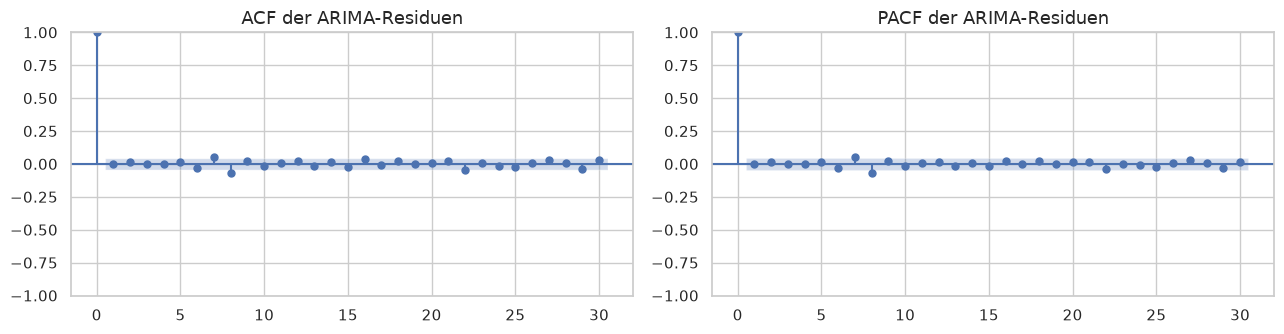

In [20]:
# Ljung-Box-Test auf in-sample Residuen des besten ARIMA-Modells
_arima_fit = fit_sarimax(ARIMA_ORDER, ARIMA_SEASONAL)
_resid = pd.Series(_arima_fit.resid).dropna()

lb_result = acorr_ljungbox(_resid, lags=[10, 20], return_df=True)
print(f"Ljung-Box-Test auf ARIMA{ARIMA_ORDER}×SARIMA{ARIMA_SEASONAL} Residuen:")
print(lb_result.to_string())
for lag, row in lb_result.iterrows():
    verdict = "H0 nicht verworfen (kein Hinweis auf Reststruktur)" \
              if row["lb_pvalue"] >= 0.05 \
              else "H0 VERWORFEN — Residuen enthalten noch Autokorrelation!"
    print(f"  Lag {lag:2d}: p={row['lb_pvalue']:.4f}  =>  {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(_resid,  lags=30, ax=axes[0], title="ACF der ARIMA-Residuen")
plot_pacf(_resid, lags=30, ax=axes[1], title="PACF der ARIMA-Residuen", method="ywm")
plt.tight_layout(); plt.show()

### 6.3  LSTM mit eigenständiger Hyperparameter-Optimierung

Auch das **LSTM** soll sich selbst optimieren. Statt einer festen Architektur
durchsuchen wir einen **erweiterten Suchraum** verschiedener Konfigurationen und
wählen automatisch die beste Variante aus. Variiert werden:

* **Anzahl der LSTM-Schichten** (1, 2 oder 3 gestapelte Schichten),
* **Anzahl der Neuronen** je Schicht (32 / 64 / 128),
* **Dropout-Rate** zur Regularisierung (0.1 – 0.3),
* **Lernrate** des Adam-Optimizers ($10^{-3}$ vs. $5\cdot10^{-4}$).

Jede Konfiguration wird auf den **Trainingsdaten** trainiert (mit
**EarlyStopping** auf der Validierungsmenge) und anhand des **Validierungs-RMSE**
(im Preisraum) bewertet. Ausgewählt wird das Modell mit dem geringsten
Validierungsfehler – die Testmenge bleibt dabei unberührt (keine Modellselektion
auf Testdaten).

> Ohne TensorFlow weicht das Notebook auf einen `scikit-learn`-MLP aus; die
> Auswahllogik bleibt strukturell identisch.

In [21]:
class KerasLSTM:
    """Konfigurierbares Keras-LSTM mit einheitlicher predict()-Schnittstelle."""
    def __init__(self, window, n_feat, units=(64, 32), dropout=0.2, lr=1e-3):
        from tensorflow.keras.optimizers import Adam
        layers = [Input(shape=(window, n_feat))]
        for i, u in enumerate(units):
            layers.append(LSTM(u, return_sequences=(i < len(units) - 1)))
            layers.append(Dropout(dropout))
        layers.append(Dense(1))
        self.model = Sequential(layers)
        self.model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    def fit(self, Xtr, ytr, Xv, yv, epochs=SEARCH_EPOCHS, patience=8):
        es = EarlyStopping(monitor="val_loss", patience=patience,
                           restore_best_weights=True)
        self.history = self.model.fit(Xtr, ytr, validation_data=(Xv, yv),
                                      epochs=epochs, batch_size=BATCH,
                                      callbacks=[es], verbose=0)
        return self
    def predict(self, X):
        return self.model.predict(X, verbose=0).ravel()

class MLPFallback:
    """Fallback ohne TensorFlow: MLP auf geflatteten Sliding-Windows."""
    def __init__(self, window, n_feat, **kw):
        from sklearn.neural_network import MLPRegressor
        self.model = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=300,
                                  early_stopping=True, random_state=SEED)
        self.history = None
    def fit(self, Xtr, ytr, Xv, yv, **kw):
        self.model.fit(Xtr.reshape(len(Xtr), -1), ytr); return self
    def predict(self, X):
        return self.model.predict(X.reshape(len(X), -1))

def val_rmse_price(m):
    """Validierungs-RMSE im Preisraum (USD)."""
    p = close_scaler.inverse_transform(m.predict(X_val).reshape(-1, 1)).ravel()
    return float(np.sqrt(mean_squared_error(feat[TARGET].values[idx_val], p)))

In [22]:
def build_and_train(cfg, epochs):
    # Reproduzierbar trainieren; clear_session gibt den Graphen des Vorlaufs frei
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    m = KerasLSTM(WINDOW, len(FEATURES), units=cfg["units"],
                  dropout=cfg["dropout"], lr=cfg["lr"])
    m.fit(X_train, y_train, X_val, y_val, epochs=epochs)
    return m

hpo_rows, best_rmse, best_cfg = [], np.inf, None
if HAS_TF:
    # --- Suche: jede Konfiguration trainieren und am Val-RMSE bewerten -------
    for cfg in tqdm(LSTM_SEARCH_SPACE, desc="LSTM-HPO", unit="Konfiguration"):
        m    = build_and_train(cfg, SEARCH_EPOCHS)
        rmse = val_rmse_price(m)
        ep   = len(m.history.history["loss"])
        hpo_rows.append({"Schichten": len(cfg["units"]), "Neuronen": str(cfg["units"]),
                         "Dropout": cfg["dropout"], "LR": cfg["lr"],
                         "Epochen": ep, "Val_RMSE": rmse})
        print(f"  units={str(cfg['units']):14s} dropout={cfg['dropout']:.2f} "
              f"lr={cfg['lr']:.0e} -> Val-RMSE={rmse:7.3f}  ({ep} Epochen)")
        if rmse < best_rmse:
            best_rmse, best_cfg = rmse, cfg

    hpo_df = pd.DataFrame(hpo_rows).sort_values("Val_RMSE").reset_index(drop=True)
    print("\n=== Hyperparameter-Suche (sortiert nach Validierungs-RMSE) ===")
    print(hpo_df.to_string(index=False))
    print(f"\n==> Beste Konfiguration: units={best_cfg['units']}, "
          f"dropout={best_cfg['dropout']}, lr={best_cfg['lr']:.0e}  "
          f"(Val-RMSE={best_rmse:.3f})")

    # --- Bestes Modell deterministisch neu trainieren (identischer Seed) -----
    model      = build_and_train(best_cfg, SEARCH_EPOCHS)
    model_name = f"LSTM* {best_cfg['units']}/d{best_cfg['dropout']}"
else:
    model      = MLPFallback(WINDOW, len(FEATURES)).fit(X_train, y_train, X_val, y_val)
    model_name = "MLP-Fallback"
    print("TensorFlow nicht verfügbar -> MLP-Fallback genutzt.")

LSTM-HPO:   0%|          | 0/8 [00:00<?, ?Konfiguration/s]

LSTM-HPO:  12%|█▎        | 1/8 [00:16<01:53, 16.15s/Konfiguration]

  units=(32,)          dropout=0.10 lr=1e-03 -> Val-RMSE=  1.692  (25 Epochen)


LSTM-HPO:  25%|██▌       | 2/8 [00:36<01:53, 18.84s/Konfiguration]

  units=(64,)          dropout=0.20 lr=1e-03 -> Val-RMSE=  1.292  (25 Epochen)


...

LSTM-HPO:  88%|████████▊ | 7/8 [04:32<00:43, 43.66s/Konfiguration]

  units=(64, 32)       dropout=0.30 lr=5e-04 -> Val-RMSE=  1.888  (23 Epochen)


LSTM-HPO: 100%|██████████| 8/8 [05:53<00:00, 55.63s/Konfiguration]

LSTM-HPO: 100%|██████████| 8/8 [05:53<00:00, 44.24s/Konfiguration]

  units=(128, 64, 32)  dropout=0.30 lr=5e-04 -> Val-RMSE=  2.094  (25 Epochen)

=== Hyperparameter-Suche (sortiert nach Validierungs-RMSE) ===
 Schichten      Neuronen  Dropout     LR  Epochen  Val_RMSE
         1        (128,)   0.2000 0.0010       25    1.2071
         1         (64,)   0.2000 0.0010       25    1.2921
         2     (128, 64)   0.3000 0.0010       25    1.5147
         2     (128, 64)   0.2000 0.0005       22    1.6220
         1         (32,)   0.1000 0.0010       25    1.6922
         2      (64, 32)   0.2000 0.0010       25    1.7385
         2      (64, 32)   0.3000 0.0005       23    1.8882
         3 (128, 64, 32)   0.3000 0.0005       25    2.0937

==> Beste Konfiguration: units=(128,), dropout=0.2, lr=1e-03  (Val-RMSE=1.207)


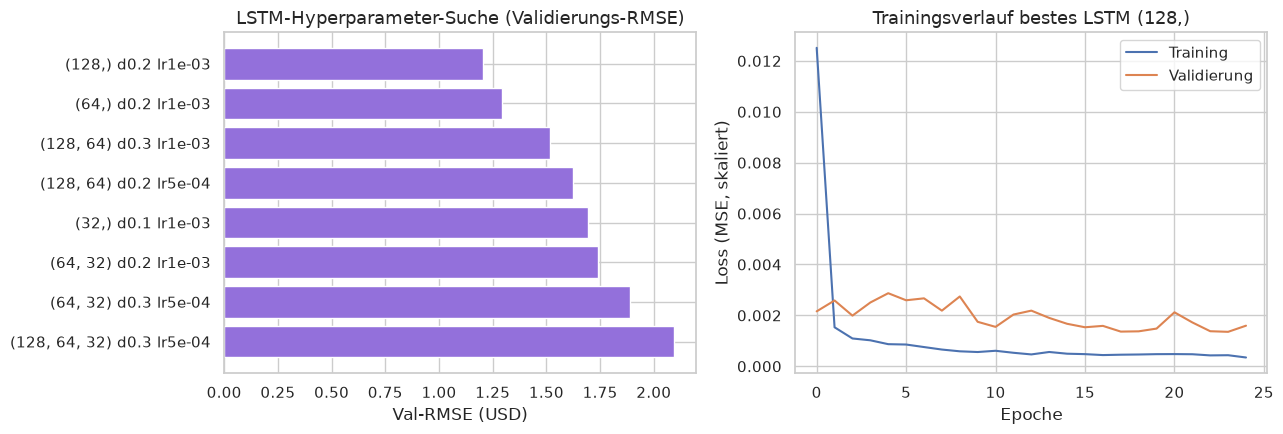

Bestes LSTM über 25 Epochen trainiert (EarlyStopping aktiv).


In [23]:
# Bestes LSTM visualisieren: Suchergebnis + Trainingsverlauf
if HAS_TF:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    labels = (hpo_df["Neuronen"] + " d" + hpo_df["Dropout"].astype(str)
              + " lr" + hpo_df["LR"].map(lambda x: f"{x:.0e}"))
    axes[0].barh(labels, hpo_df["Val_RMSE"], color="mediumpurple")
    axes[0].set(title="LSTM-Hyperparameter-Suche (Validierungs-RMSE)", xlabel="Val-RMSE (USD)")
    axes[0].invert_yaxis()
    h = model.history.history
    axes[1].plot(h["loss"], label="Training")
    axes[1].plot(h["val_loss"], label="Validierung")
    axes[1].set(title=f"Trainingsverlauf bestes LSTM {best_cfg['units']}",
                xlabel="Epoche", ylabel="Loss (MSE, skaliert)")
    axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f"Bestes LSTM über {len(h['loss'])} Epochen trainiert (EarlyStopping aktiv).")

### 6.4  Walk-Forward-Kreuzvalidierung (Zeitreihen-CV)

Ein einzelner Testabschnitt liefert nur einen Punktschätzwert der Prognosegüte –
wie stabil diese Güte über verschiedene Marktphasen ist, lässt sich daraus nicht
beurteilen. Die **Walk-Forward-Kreuzvalidierung** (auch: *Time-Series Split*)
adressiert dieses Problem durch mehrere chronologische Folds:

```
Fold 1:  ████████████ Train │███ Val │███ Test
Fold 2:  ███████████████ Train │███ Val │███ Test
Fold 3:  ██████████████████ Train │███ Val │███ Test
         ─────────────────────────────────────────► Zeit
```

Jeder Fold wird mit der **besten HPO-Architektur** (aus 6.3) schnell trainiert
(reduzierte Epochenanzahl, Early Stopping). Die Metriken je Fold werden
aggregiert: **Mittelwert ± Standardabweichung** zeigen, wie verlässlich das
Modell über verschiedene Marktphasen hinweg ist. Eine hohe Standardabweichung
deutet auf Regime-Sensitivität hin.

> **Rechenzeit:** Um die interaktive Ausführbarkeit zu gewährleisten, wird eine
> komprimierte Architektur (1 Schicht, reduzierte Epochen) genutzt. In der
> Praxis wäre die volle HPO-Architektur zu bevorzugen.

In [24]:
# Walk-Forward CV Konfiguration
CV_FOLDS       = 3    # Anzahl der Folds
CV_TRAIN_RATIO = 0.55 # Anteil für Training im ersten Fold
CV_STEP        = 0.12 # Schrittweite je Fold (= Testgröße je Fold)
CV_VAL_RATIO   = 0.15 # Validierungsanteil (relativ zur Trainingsmenge)
CV_EPOCHS      = 20   # reduzierte Epochenzahl für CV (Geschwindigkeit)

n_cv = len(feat)
cv_results = []

print(f"Walk-Forward-CV: {CV_FOLDS} Folds, Schrittweite={CV_STEP:.0%}")
print(f"{'Fold':>4}  {'Train':>5}  {'Val':>4}  {'Test':>4}  "
      f"{'MAE':>8}  {'RMSE':>8}  {'MAPE':>7}  {'Theil-U':>8}")
print("-" * 60)

for fold in range(CV_FOLDS):
    # Zeitgrenzen dieses Folds (streng vorwärts verschoben)
    end_train_frac = CV_TRAIN_RATIO + fold * CV_STEP
    end_val_frac   = end_train_frac + CV_VAL_RATIO * end_train_frac
    end_test_frac  = end_val_frac + CV_STEP

    i_tr  = int(n_cv * end_train_frac)
    i_vl  = int(n_cv * min(end_val_frac, end_train_frac + 0.10))
    i_te  = int(n_cv * min(end_test_frac, 1.0))

    if i_te <= i_vl + WINDOW:
        continue  # zu wenig Daten für diesen Fold überspringen

    # Scaler NUR auf Trainingsdaten dieses Folds fitten
    cv_feat_sc  = MinMaxScaler().fit(feat[FEATURES].iloc[:i_tr])
    cv_close_sc = MinMaxScaler().fit(feat[[TARGET]].iloc[:i_tr])
    cv_X_all    = cv_feat_sc.transform(feat[FEATURES])
    cv_y_all    = cv_close_sc.transform(feat[[TARGET]]).ravel()

    def _build_cv(lo, hi):
        Xs, ys, idx = [], [], []
        for i in range(max(lo, WINDOW), hi):
            Xs.append(cv_X_all[i-WINDOW:i])
            ys.append(cv_y_all[i])
            idx.append(i)
        return np.array(Xs), np.array(ys), np.array(idx)

    Xtr_cv, ytr_cv, _      = _build_cv(0,    i_tr)
    Xvl_cv, yvl_cv, _      = _build_cv(i_tr, i_vl)
    Xte_cv, yte_cv, idx_te = _build_cv(i_vl, i_te)

    if len(Xtr_cv) == 0 or len(Xte_cv) == 0:
        continue

    # Modell trainieren (beste HPO-Architektur, reduzierte Epochen)
    if HAS_TF:
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        cv_model = KerasLSTM(WINDOW, len(FEATURES),
                             units=best_cfg["units"],
                             dropout=best_cfg["dropout"],
                             lr=best_cfg["lr"])
        cv_model.fit(Xtr_cv, ytr_cv, Xvl_cv, yvl_cv,
                     epochs=CV_EPOCHS, patience=6)
    else:
        cv_model = MLPFallback(WINDOW, len(FEATURES)).fit(
            Xtr_cv, ytr_cv, Xvl_cv, yvl_cv)

    # Prognose -> Preisraum
    cv_pred_scaled = cv_model.predict(Xte_cv)
    cv_pred_price  = cv_close_sc.inverse_transform(
        cv_pred_scaled.reshape(-1, 1)).ravel()
    cv_true_price  = feat[TARGET].values[idx_te]

    # Naive Referenz für diesen Fold
    cv_naive_price = feat[TARGET].values[idx_te - 1]
    cv_naive_rmse  = float(np.sqrt(mean_squared_error(cv_true_price, cv_naive_price)))

    mae, _, rmse, _, mape, _ = metrics(cv_true_price, cv_pred_price)
    theil_u = rmse / (cv_naive_rmse + 1e-8)

    cv_results.append({"Fold": fold + 1, "Train": len(Xtr_cv),
                       "Val": len(Xvl_cv), "Test": len(Xte_cv),
                       "MAE": mae, "RMSE": rmse, "MAPE": mape, "Theil_U": theil_u})
    print(f"{fold+1:>4}  {len(Xtr_cv):>5}  {len(Xvl_cv):>4}  {len(Xte_cv):>4}  "
          f"{mae:>8.3f}  {rmse:>8.3f}  {mape:>7.2%}  {theil_u:>8.4f}")

cv_df = pd.DataFrame(cv_results)
print("-" * 60)
if len(cv_df) > 0:
    print(f"  Mittel  {cv_df['MAE'].mean():>8.3f}  {cv_df['RMSE'].mean():>8.3f}  "
          f"{cv_df['MAPE'].mean():>7.2%}  {cv_df['Theil_U'].mean():>8.4f}")
    print(f"  ±Std    {cv_df['MAE'].std():>8.3f}  {cv_df['RMSE'].std():>8.3f}  "
          f"{cv_df['MAPE'].std():>7.2%}  {cv_df['Theil_U'].std():>8.4f}")

Walk-Forward-CV: 3 Folds, Schrittweite=12%
Fold  Train   Val  Test       MAE      RMSE     MAPE   Theil-U
------------------------------------------------------------


   1   1312   206   299     3.051     3.731   12.74%    4.6583


   2   1611   250   300     1.181     1.631    3.95%    1.7313


   3   1911   249   275    17.884    21.695   15.16%    6.4625
------------------------------------------------------------
  Mittel     7.372     9.019   10.62%    4.2840
  ±Std       9.152    11.028    5.90%    2.3877


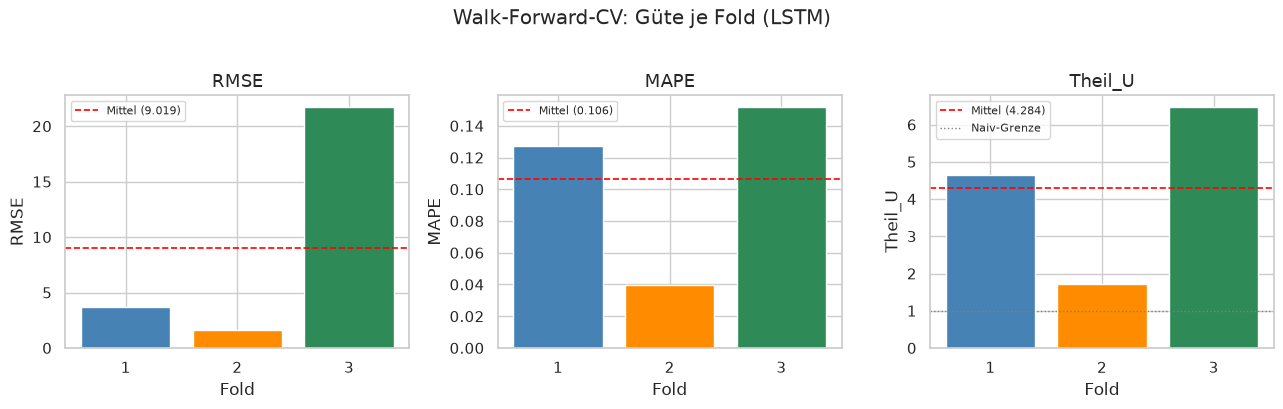


Stabilitäts-Urteil: Theil-U Mittel=4.2840, Std=2.3877
  => Modell schlägt die naive Baseline im Mittel NICHT.
  => Hohe Streuung — Prognosegüte ist marktzustandsabhängig (Regime-Sensitivität).


In [25]:
# Visualisierung der Fold-Ergebnisse
if len(cv_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for i, col in enumerate(["RMSE", "MAPE", "Theil_U"]):
        axes[i].bar(cv_df["Fold"].astype(str), cv_df[col],
                    color=["steelblue", "darkorange", "seagreen"][:len(cv_df)])
        axes[i].axhline(cv_df[col].mean(), color="red", ls="--", lw=1.2,
                        label=f"Mittel ({cv_df[col].mean():.3f})")
        if col == "Theil_U":
            axes[i].axhline(1.0, color="gray", ls=":", lw=1, label="Naiv-Grenze")
        axes[i].set(title=col, xlabel="Fold", ylabel=col)
        axes[i].legend(fontsize=8)
    plt.suptitle("Walk-Forward-CV: Güte je Fold (LSTM)", y=1.02)
    plt.tight_layout(); plt.show()

    print(f"\nStabilitäts-Urteil: Theil-U Mittel={cv_df['Theil_U'].mean():.4f}, "
          f"Std={cv_df['Theil_U'].std():.4f}")
    if cv_df["Theil_U"].mean() < 1.0:
        print("  => Modell schlägt im Mittel die naive Baseline.")
    else:
        print("  => Modell schlägt die naive Baseline im Mittel NICHT.")
    if cv_df["Theil_U"].std() > 0.15:
        print("  => Hohe Streuung — Prognosegüte ist marktzustandsabhängig (Regime-Sensitivität).")

**Interpretation der Walk-Forward-CV.** Die Standardabweichung der Metriken über
die Folds ist ein direktes Maß für die **Stabilität** des Modells. Typisch für
Aktienkursprognosen:

* Bei ruhigen, trendenden Marktphasen (Fold auf relativ geglättetem Niveau) sind
  RMSE und Theil-U tendenziell günstiger als bei volatilen Phasen.
* Ist die Streuung hoch, sollte man sich nicht auf einen einzelnen (günstigen)
  Testabschnitt verlassen – der **CV-Mittelwert** ist das ehrlichere Gütemaß.
* Liegt Theil-U im Mittel nahe 1, bestätigt dies den Befund aus Kap. 8: Das
  Modell bietet keinen robusten Vorteil gegenüber der naiven Baseline.

### 6.5  Alternatives Modell: LSTM auf Log-Renditen (stationäre Zielvariable)

Die in Kap. 4.3 und 8.1 diskutierte **Niveau-Lag-Problematik** entsteht, weil das
Kursniveau selbst *nicht-stationär* ist: Das Modell „lernt" vorwiegend, den
Vortageswert zu reproduzieren, statt echte Muster zu extrahieren.

Eine methodisch sauberere Alternative modelliert daher die **tagesweise
Log-Rendite** $r_t = \ln(P_t / P_{t-1})$ als Zielgröße – denn Renditen sind
(gemäß Kap. 4.3) stationär und enthalten ggf. ausschöpfbare Korrelationsstrukturen.

**Ablauf:**

1. `return_scaler` wird – wie `close_scaler` – nur auf Trainingsdaten gefittet.
2. Gleiche Feature-Matrix $X$ (FEATURES, skaliert), aber als Zielvektor $y$:
   die skalierten Log-Renditen.
3. Eine **eigenständige Hyperparameter-Suche** (identischer Suchraum wie in
   Kap. 6.3, aber bewertet am rücktransformierten Validierungs-RMSE im
   Preisraum) bestimmt die für diese Zielvariable beste Architektur — die
   beste Konfiguration des Level-Modells muss hier nicht optimal sein, da
   Zielskala und -verteilung unterschiedlich sind.
4. **Rücktransformation in den Preisraum:** $\hat{P}_t = P_{t-1} \cdot e^{\hat{r}_t}$.

Damit ist ein direkter Vergleich mit den übrigen Modellen möglich, da alle
Metriken im **Preisraum (USD)** berechnet werden.

In [26]:
# Scaler für Log-Rendite (nur auf Trainingsdaten)
return_scaler = MinMaxScaler().fit(feat[["LogReturn"]].iloc[:i_train])
lr_all = return_scaler.transform(feat[["LogReturn"]]).ravel()

def build_windows_ret(lo, hi):
    '''Sliding-Windows mit Log-Rendite als Ziel (gleiche Feature-Matrix X).'''
    Xs, ys, idx = [], [], []
    start = max(lo, WINDOW)
    for i in range(start, hi):
        Xs.append(X_all[i - WINDOW : i])
        ys.append(lr_all[i])
        idx.append(i)
    return np.array(Xs), np.array(ys), np.array(idx)

X_train_r, y_train_r, idx_train_r = build_windows_ret(0,       i_train)
X_val_r,   y_val_r,   idx_val_r   = build_windows_ret(i_train, i_val)
X_test_r,  y_test_r,  idx_test_r  = build_windows_ret(i_val,   n)

print(f"Fenster (Log-Renditen): X_train={X_train_r.shape}  X_val={X_val_r.shape}  X_test={X_test_r.shape}")
print(f"Ziel-Mittelwert (skaliert): {y_train_r.mean():.4f}  Std: {y_train_r.std():.4f}")

Fenster (Log-Renditen): X_train=(1686, 60, 9)  X_val=(374, 60, 9)  X_test=(375, 60, 9)
Ziel-Mittelwert (skaliert): 0.4483  Std: 0.0617


In [27]:
# --- Eigenstaendige HPO-Suche fuer das Log-Renditen-LSTM ---------------------
# Andere Zielskala/-verteilung als das Level-LSTM (Kap. 6.3) - die dort beste
# Architektur ist hier nicht automatisch optimal. Gleicher LSTM_SEARCH_SPACE,
# aber Bewertung am ruecktransformierten Validierungs-RMSE im Preisraum, damit
# die Auswahl direkt mit Kap. 6.3 vergleichbar ist.

def val_rmse_return(m):
    """Validierungs-RMSE im Preisraum (USD) nach Ruecktransformation der Renditen-Prognose."""
    r_scaled = m.predict(X_val_r)
    r_pred   = return_scaler.inverse_transform(r_scaled.reshape(-1, 1)).ravel()
    p_pred   = feat["Close"].values[idx_val_r - 1] * np.exp(r_pred)
    p_true   = feat[TARGET].values[idx_val_r]
    return float(np.sqrt(mean_squared_error(p_true, p_pred)))

def build_and_train_r(cfg, epochs):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    m = KerasLSTM(WINDOW, len(FEATURES), units=cfg["units"],
                  dropout=cfg["dropout"], lr=cfg["lr"])
    m.fit(X_train_r, y_train_r, X_val_r, y_val_r, epochs=epochs)
    return m

if HAS_TF:
    hpo_rows_r, best_rmse_r, best_cfg_r = [], np.inf, None
    for cfg in tqdm(LSTM_SEARCH_SPACE, desc="LSTM-HPO (Log-Rendite)", unit="Konfiguration"):
        m    = build_and_train_r(cfg, SEARCH_EPOCHS)
        rmse = val_rmse_return(m)
        ep   = len(m.history.history["loss"])
        hpo_rows_r.append({"Schichten": len(cfg["units"]), "Neuronen": str(cfg["units"]),
                           "Dropout": cfg["dropout"], "LR": cfg["lr"],
                           "Epochen": ep, "Val_RMSE": rmse})
        print(f"  units={str(cfg['units']):14s} dropout={cfg['dropout']:.2f} "
              f"lr={cfg['lr']:.0e} -> Val-RMSE={rmse:7.3f}  ({ep} Epochen)")
        if rmse < best_rmse_r:
            best_rmse_r, best_cfg_r = rmse, cfg

    hpo_df_r = pd.DataFrame(hpo_rows_r).sort_values("Val_RMSE").reset_index(drop=True)
    print("\n=== Hyperparameter-Suche Log-Renditen-LSTM (sortiert nach Validierungs-RMSE) ===")
    print(hpo_df_r.to_string(index=False))
    print(f"\n==> Beste Konfiguration: units={best_cfg_r['units']}, "
          f"dropout={best_cfg_r['dropout']}, lr={best_cfg_r['lr']:.0e}  "
          f"(Val-RMSE={best_rmse_r:.3f} USD)")

    # --- Bestes Renditen-Modell deterministisch neu trainieren ---------------
    model_ret = build_and_train_r(best_cfg_r, FINAL_EPOCHS)
    h_ret = model_ret.history.history
    print(f"Log-Renditen-LSTM trainiert: {len(h_ret['loss'])} Epochen "
          f"(Val-Loss final: {h_ret['val_loss'][-1]:.6f})")
else:
    model_ret = MLPFallback(WINDOW, len(FEATURES)).fit(
        X_train_r, y_train_r, X_val_r, y_val_r)
    best_cfg_r, hpo_df_r = {"units": "MLP-Fallback"}, pd.DataFrame()
    print("TensorFlow nicht verfuegbar -> MLP-Fallback auf Log-Renditen trainiert.")


LSTM-HPO (Log-Rendite):   0%|          | 0/8 [00:00<?, ?Konfiguration/s]

LSTM-HPO (Log-Rendite):  12%|█▎        | 1/8 [00:16<01:54, 16.39s/Konfiguration]

  units=(32,)          dropout=0.10 lr=1e-03 -> Val-RMSE=  0.868  (25 Epochen)


LSTM-HPO (Log-Rendite):  25%|██▌       | 2/8 [00:38<01:56, 19.49s/Konfiguration]

  units=(64,)          dropout=0.20 lr=1e-03 -> Val-RMSE=  0.862  (25 Epochen)


...

  units=(64, 32)       dropout=0.30 lr=5e-04 -> Val-RMSE=  0.876  (16 Epochen)


LSTM-HPO (Log-Rendite): 100%|██████████| 8/8 [04:04<00:00, 37.64s/Konfiguration]

LSTM-HPO (Log-Rendite): 100%|██████████| 8/8 [04:04<00:00, 30.57s/Konfiguration]

  units=(128, 64, 32)  dropout=0.30 lr=5e-04 -> Val-RMSE=  0.863  (19 Epochen)

=== Hyperparameter-Suche Log-Renditen-LSTM (sortiert nach Validierungs-RMSE) ===
 Schichten      Neuronen  Dropout     LR  Epochen  Val_RMSE
         1         (64,)   0.2000 0.0010       25    0.8623
         3 (128, 64, 32)   0.3000 0.0005       19    0.8628
         1         (32,)   0.1000 0.0010       25    0.8676
         2      (64, 32)   0.2000 0.0010       16    0.8703
         1        (128,)   0.2000 0.0010       23    0.8720
         2     (128, 64)   0.2000 0.0005       10    0.8733
         2      (64, 32)   0.3000 0.0005       16    0.8760
         2     (128, 64)   0.3000 0.0010        9    0.8766

==> Beste Konfiguration: units=(64,), dropout=0.2, lr=1e-03  (Val-RMSE=0.862 USD)


Log-Renditen-LSTM trainiert: 26 Epochen (Val-Loss final: 0.007127)


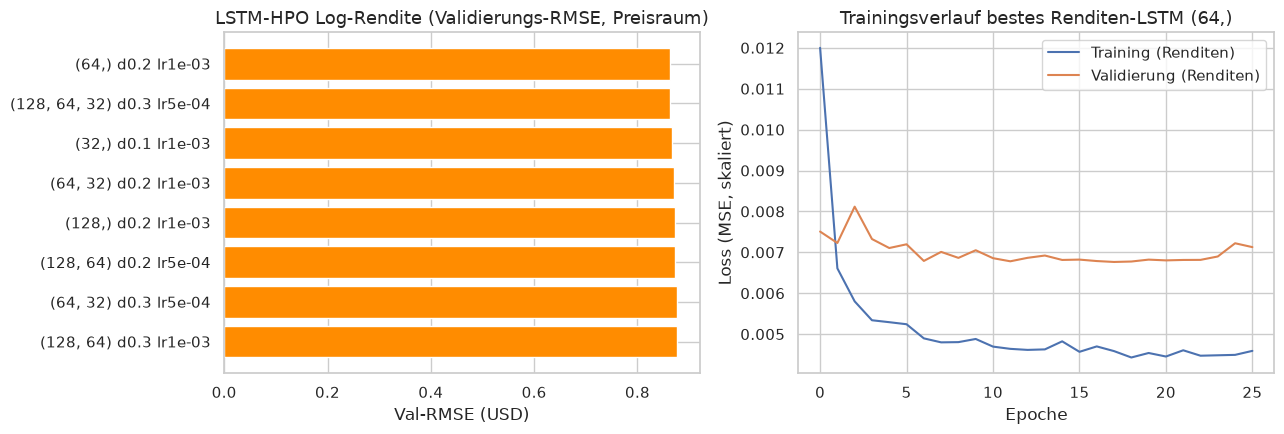

Bestes Renditen-LSTM ueber 26 Epochen trainiert (EarlyStopping aktiv).


In [28]:
# Renditen-LSTM visualisieren: Suchergebnis + Trainingsverlauf
if HAS_TF:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    labels_r = (hpo_df_r["Neuronen"] + " d" + hpo_df_r["Dropout"].astype(str)
               + " lr" + hpo_df_r["LR"].map(lambda x: f"{x:.0e}"))
    axes[0].barh(labels_r, hpo_df_r["Val_RMSE"], color="darkorange")
    axes[0].set(title="LSTM-HPO Log-Rendite (Validierungs-RMSE, Preisraum)", xlabel="Val-RMSE (USD)")
    axes[0].invert_yaxis()
    axes[1].plot(h_ret["loss"],     label="Training (Renditen)")
    axes[1].plot(h_ret["val_loss"], label="Validierung (Renditen)")
    axes[1].set(title=f"Trainingsverlauf bestes Renditen-LSTM {best_cfg_r['units']}",
                xlabel="Epoche", ylabel="Loss (MSE, skaliert)")
    axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f"Bestes Renditen-LSTM ueber {len(h_ret['loss'])} Epochen trainiert (EarlyStopping aktiv).")


In [29]:
# Rücktransformation in den Preisraum: P_t = P_{t-1} * exp(r_hat_t)
ret_scaled = model_ret.predict(X_test_r)
ret_pred   = return_scaler.inverse_transform(ret_scaled.reshape(-1, 1)).ravel()

# Vortagespreis: letzter Tag im Eingabefenster = idx_test_r - 1
prev_prices_r = feat["Close"].values[idx_test_r - 1]
lstm_ret_pred = prev_prices_r * np.exp(ret_pred)

y_test_price_r = feat[TARGET].values[idx_test_r]   # Referenzpreise (deckungsgleich mit idx_test)

results["LSTM (Log-Rendite)"] = metrics(y_test_price_r, lstm_ret_pred)
_m = results["LSTM (Log-Rendite)"]
print(f"LSTM (Log-Rendite)  MAE={_m[0]:.3f}  RMSE={_m[2]:.3f}  "
      f"R²={_m[3]:+.4f}  MAPE={_m[4]:.2%}  sMAPE={_m[5]:.2%}")

# Kurzvergleich Level- vs. Rendite-Modell im Preisraum
_lv_pred = close_scaler.inverse_transform(model.predict(X_test).reshape(-1, 1)).ravel()  # Level-LSTM aus Kap. 6.3, results[model_name] wird erst in Kap. 7.1 befuellt
_lv = metrics(y_test_price, _lv_pred)
naive_rmse_ref = results["Naiv (P_{t-1})"][2]
print(f"\nVergleich auf Testmenge (Preisraum):")
print(f"  LSTM (Kurs-Level)   RMSE={_lv[2]:.3f}  MAPE={_lv[4]:.2%}  Theil-U={_lv[2]/naive_rmse_ref:.4f}")
print(f"  LSTM (Log-Rendite)  RMSE={_m[2]:.3f}  MAPE={_m[4]:.2%}  Theil-U={_m[2]/naive_rmse_ref:.4f}")

LSTM (Log-Rendite)  MAE=2.267  RMSE=3.302  R²=+0.9918  MAPE=2.44%  sMAPE=2.44%



Vergleich auf Testmenge (Preisraum):
  LSTM (Kurs-Level)   RMSE=16.531  MAPE=10.44%  Theil-U=5.6469
  LSTM (Log-Rendite)  RMSE=3.302  MAPE=2.44%  Theil-U=1.1280


**Interpretation.** Ob das Renditen-Modell besser abschneidet als das
Level-Modell, hängt vom konkreten Datensatz ab. In der Praxis beobachtet man
häufig:

* **Vorteil Renditen-Modell:** Die Zielvariable ist stationär, sodass das Modell
  keine Scheinkonstanz der „$P_t \approx P_{t-1}$"-Struktur lernt.
* **Nachteil / Herausforderung:** Durch die Rücktransformation per Exp-Summe
  können sich kleine Renditenfehler über viele Schritte akkumulieren; außerdem
  ist die Renditeverteilung nahezu weißes Rauschen (vgl. Kap. 4.3), was die
  Vorhersagbarkeit prinzipiell begrenzt.

Das Renditen-Modell ergänzt damit die kritische Einordnung aus Kap. 8: Es
überprüft, ob die beobachtete Güte des Level-Modells wirklich gelernte Struktur
widerspiegelt – oder nur die **Persistenz-Eigenschaft** des Kursniveaus ausnutzt.

## 7  Evaluation und Explainability

### 7.1  Evaluationsmetriken und Modellvergleich

Wir transformieren die skalierten LSTM-Prognosen zurück in den **Preisraum** (USD)
und bewerten alle Modelle auf der **Testmenge** mit einem erweiterten Metrik-Set:

| Metrik | Interpretation | Einheit |
|---|---|---|
| **MAE** | Mittlerer absoluter Fehler | USD |
| **RMSE** | Wurzel des mittl. quadr. Fehlers; bestraft Ausreißer stärker | USD |
| **R²** | Anteil erklärter Varianz; bei trendenden Niveaureihen oft trügerisch hoch | – |
| **MAPE** | Mittlerer absoluter prozentualer Fehler; skalenunabhängig | % |
| **sMAPE** | Symmetrische MAPE; robuster bei kleinen/großen $y_t$ | % |
| **Theil's U** | $\text{RMSE}_\text{Modell}/\text{RMSE}_\text{Naiv}$: $<1$ = besser als Naiv | – |

> **Hinweis zu R²:** Bei stark trendenden Kursniveaus ist R² für *alle* Modelle
> nahezu 1 — auch die naive Prognose erklärt fast die gesamte Varianz, weil
> $P_t \approx P_{t-1}$. Aussagekräftiger ist **Theil's U**, das direkt gegen
> die naive Baseline normiert und zeigt, ob ein Modell *über den Zufall hinaus*
> Struktur ausschöpft.

Verglichen werden alle vier Modellfamilien: naive Baseline, Moving-Average,
**auto-optimiertes ARIMA/SARIMA** (Kap. 6.2) und **HPO-optimiertes LSTM** (Kap. 6.3).

In [30]:
# LSTM-Prognosen (bestes Modell aus der HPO) -> Preisraum
lstm_pred_scaled = model.predict(X_test)
lstm_pred = close_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()
results[model_name] = metrics(y_test_price, lstm_pred)   # model_name aus Kap. 6.3

res_df = pd.DataFrame(results,
                      index=["MAE", "MSE", "RMSE", "R²", "MAPE", "sMAPE"]).T
naive_rmse = results["Naiv (P_{t-1})"][2]
res_df["Theil_U"] = res_df["RMSE"] / naive_rmse
res_df = res_df.sort_values("RMSE")

print("=== Prognosegüte auf der Testmenge ===")
_show = res_df[["MAE", "RMSE", "R²", "MAPE", "sMAPE", "Theil_U"]].copy()
_show["MAPE"]  = _show["MAPE"].map(lambda x: f"{x:.2%}")
_show["sMAPE"] = _show["sMAPE"].map(lambda x: f"{x:.2%}")
print(_show.round(4).to_string())

best = res_df.index[0]
print(f"\nBestes Modell nach RMSE: {best}")
for name in [n for n in results if n != "Naiv (P_{t-1})"]:
    u = res_df.loc[name, "Theil_U"]
    print(f"  {name:28s}  Theil-U={u:.4f}  "
          f"({'besser' if u < 1 else 'schlechter/gleich'} als naive Baseline)")

=== Prognosegüte auf der Testmenge ===
                          MAE    RMSE     R²    MAPE   sMAPE  Theil_U
ARIMA/SARIMA*          2.0337  2.9211 0.9936   2.25%   2.26%   0.9978
Naiv (P_{t-1})         2.0293  2.9273 0.9936   2.24%   2.25%   1.0000
LSTM (Log-Rendite)     2.2674  3.3022 0.9918   2.44%   2.44%   1.1280
Moving Average (MA20)  5.6452  7.5391 0.9575   6.36%   6.53%   2.5754
LSTM* (128,)/d0.2     11.7464 16.5305 0.7955  10.44%  11.36%   5.6469

Bestes Modell nach RMSE: ARIMA/SARIMA*
  Moving Average (MA20)         Theil-U=2.5754  (schlechter/gleich als naive Baseline)
  ARIMA/SARIMA*                 Theil-U=0.9978  (besser als naive Baseline)
  LSTM (Log-Rendite)            Theil-U=1.1280  (schlechter/gleich als naive Baseline)
  LSTM* (128,)/d0.2             Theil-U=5.6469  (schlechter/gleich als naive Baseline)


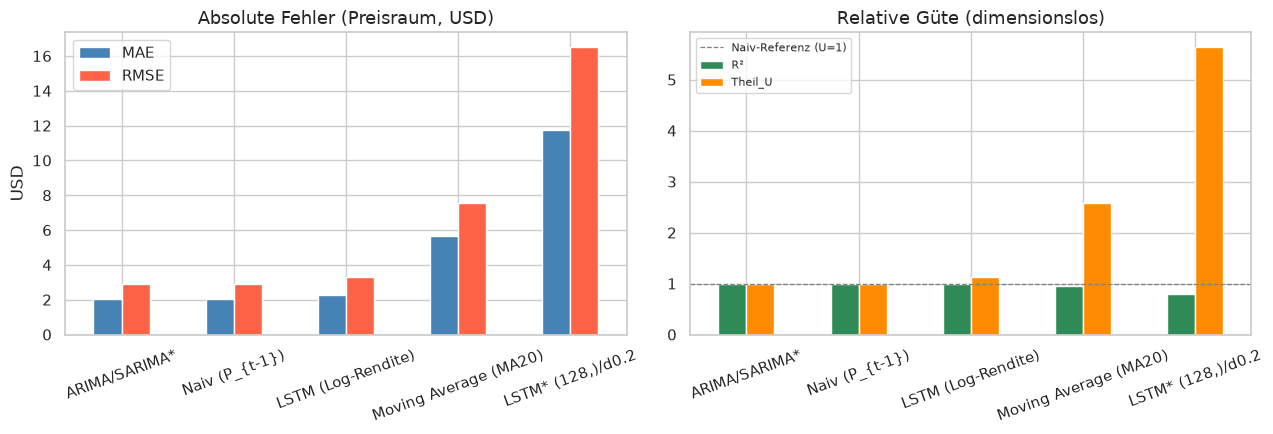

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
res_df[["MAE", "RMSE"]].plot.bar(ax=axes[0], color=["steelblue", "tomato"])
axes[0].set(title="Absolute Fehler (Preisraum, USD)", ylabel="USD", xlabel="")
axes[0].tick_params(axis="x", rotation=20)
res_df[["R²", "Theil_U"]].plot.bar(ax=axes[1], color=["seagreen", "darkorange"])
axes[1].axhline(1.0, color="gray", lw=0.9, ls="--", label="Naiv-Referenz (U=1)")
axes[1].axhline(0.0, color="black", lw=0.6, ls=":")
axes[1].set(title="Relative Güte (dimensionslos)", xlabel="")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 7.1b  Benchmark gegen Monte-Carlo-Random-Walk-Simulation

Reicht reiner Zufall aus, um ähnliche Fehlerwerte wie die trainierten Modelle
zu erzielen? Wir simulieren $N=1\,000$ **Random-Walk-Pfade** (geometrische
Brownsche Bewegung) über den Testzeitraum, kalibriert ausschließlich auf den
**Trainings**-Tagesrenditen ($\mu$, $\sigma$ der Log-Renditen), und vergleichen
die resultierende RMSE-Verteilung mit dem tatsächlichen LSTM- und Naiv-Fehler.
Liegt der LSTM-RMSE innerhalb dieser Zufallsverteilung, liefert das Modell
keinen messbaren Mehrwert gegenüber reinem Rauschen.

In [32]:
N_PATHS = 1000
rng_mc = np.random.default_rng(SEED)

train_log_ret = feat["LogReturn"].values[idx_train]
mu_mc, sigma_mc = train_log_ret.mean(), train_log_ret.std()

h  = len(y_test_price)                        # Prognosehorizont (Testtage)
p0 = feat[TARGET].values[idx_test[0] - 1]     # letzter bekannter Kurs vor dem Testfenster

shocks   = rng_mc.normal(mu_mc, sigma_mc, size=(N_PATHS, h))
mc_paths = p0 * np.exp(np.cumsum(shocks, axis=1))
mc_rmse  = np.sqrt(((mc_paths - y_test_price) ** 2).mean(axis=1))

lstm_rmse_mc  = res_df.loc[model_name, "RMSE"]
naive_rmse_mc = res_df.loc["Naiv (P_{t-1})", "RMSE"]
pctile        = (mc_rmse < lstm_rmse_mc).mean() * 100

print(f"Random-Walk-Simulation: {N_PATHS} Pfade, mu={mu_mc:.5f}, sigma={sigma_mc:.5f} (taeglich, aus Trainingsdaten)")
print(f"RMSE Monte-Carlo (Median)     : {np.median(mc_rmse):.3f} USD")
print(f"RMSE Monte-Carlo (5.-95. Pct.): [{np.percentile(mc_rmse, 5):.3f}, {np.percentile(mc_rmse, 95):.3f}] USD")
print(f"RMSE {model_name:<24}: {lstm_rmse_mc:.3f} USD  (besser als {pctile:.1f}% der Zufallspfade)")
print(f"RMSE Naiv (P_t-1)             : {naive_rmse_mc:.3f} USD")

Random-Walk-Simulation: 1000 Pfade, mu=0.00234, sigma=0.02889 (taeglich, aus Trainingsdaten)
RMSE Monte-Carlo (Median)     : 36.526 USD
RMSE Monte-Carlo (5.-95. Pct.): [16.448, 65.765] USD
RMSE LSTM* (128,)/d0.2       : 16.531 USD  (besser als 5.3% der Zufallspfade)
RMSE Naiv (P_t-1)             : 2.927 USD


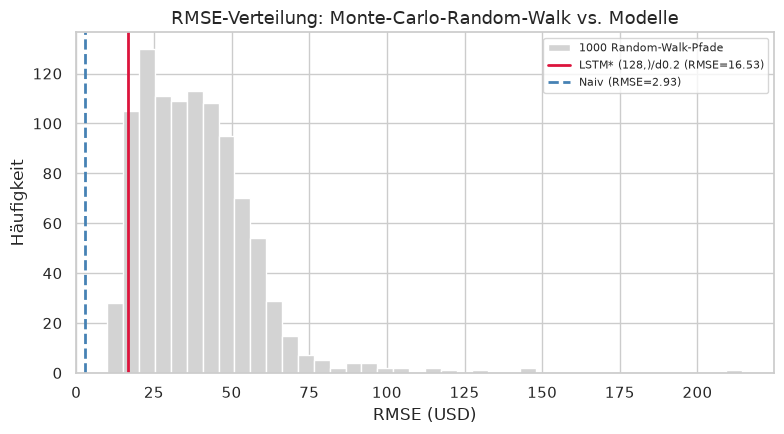

In [33]:
plt.figure(figsize=(8, 4.5))
plt.hist(mc_rmse, bins=40, color="lightgray", edgecolor="white",
         label=f"{N_PATHS} Random-Walk-Pfade")
plt.axvline(lstm_rmse_mc, color="crimson", lw=2, label=f"{model_name} (RMSE={lstm_rmse_mc:.2f})")
plt.axvline(naive_rmse_mc, color="steelblue", lw=2, ls="--",
            label=f"Naiv (RMSE={naive_rmse_mc:.2f})")
plt.xlabel("RMSE (USD)"); plt.ylabel("Häufigkeit")
plt.title("RMSE-Verteilung: Monte-Carlo-Random-Walk vs. Modelle")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

**Interpretation.** Liegt der LSTM-RMSE deutlich **unterhalb** der 5.-Perzentile
der simulierten Zufallsverteilung, ist die Prognosegüte statistisch von reinem
Rauschen zu unterscheiden. Liegt er hingegen **innerhalb** der Verteilung
(typischer Fall bei nahezu Random-Walk-Kursen, vgl. Kap. 4.3 und 8.3), erklärt
reiner Zufall einen vergleichbaren Fehler – ein starkes Indiz dafür, dass das
Modell keine über den Zufall hinausgehende Struktur ausschöpft.

### 7.1c  Statistische Signifikanztests (LSTM vs. Naive Baseline)

Ein niedrigerer RMSE allein belegt noch keinen **signifikanten** Unterschied in
der Prognosegüte. Wir prüfen daher formal, ob sich die Fehler des LSTM
signifikant von denen der naiven Baseline unterscheiden:

* **Diebold-Mariano-Test** (parametrisch): $H_0$: gleiche erwartete Verlustdifferenz
  ($E[d_t]=0$ mit $d_t = e_{\text{LSTM},t}^2 - e_{\text{Naiv},t}^2$). Wir verwenden
  die Kleinstichprobenkorrektur nach Harvey, Leybourne & Newbold (1997).
* **Wilcoxon-Vorzeichen-Rang-Test** (nichtparametrisch, robust gegenüber
  Ausreißern/Nicht-Normalität): $H_0$: die absoluten Fehler beider Modelle stammen
  aus derselben Verteilung (paarweiser Vergleich pro Testtag).

In [34]:
def diebold_mariano(e1, e2, h=1, power=2):
    '''Diebold-Mariano-Test (Harvey/Leybourne/Newbold-korrigiert).
    e1, e2: Fehlervektoren (y_true - y_pred) der beiden zu vergleichenden Modelle.
    H0: gleiche Prognosegüte. Negative Statistik => Modell 1 (e1) ist besser.
    Rückgabe: (DM-Statistik, p-Wert)
    '''
    d = np.abs(e1) ** power - np.abs(e2) ** power
    n = len(d)
    dbar = d.mean()

    gamma0 = np.var(d, ddof=0)
    var_d = gamma0
    for lag in range(1, h):
        cov = np.cov(d[lag:], d[:-lag])[0, 1]
        var_d += 2 * (1 - lag / h) * cov
    var_d /= n

    dm_stat = dbar / np.sqrt(var_d)
    hln = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)   # Kleinstichprobenkorrektur
    dm_stat_corr = dm_stat * hln
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat_corr), df=n - 1))
    return dm_stat_corr, p_value

resid_lstm_sig  = y_test_price - lstm_pred
resid_naive_sig = y_test_price - naive_pred

dm_stat, dm_p = diebold_mariano(resid_lstm_sig, resid_naive_sig, h=1, power=2)
print("=== Diebold-Mariano-Test (LSTM vs. Naiv, quadratischer Verlust) ===")
print(f"  DM-Statistik : {dm_stat:.4f}")
print(f"  p-Wert       : {dm_p:.4g}")
if dm_p < 0.05:
    dm_verdict = "LSTM signifikant besser" if dm_stat < 0 else "Naiv signifikant besser"
else:
    dm_verdict = "kein signifikanter Unterschied"
print(f"  => {dm_verdict}  (alpha=0.05)\n")

wstat, wp = stats.wilcoxon(np.abs(resid_lstm_sig), np.abs(resid_naive_sig))
print("=== Wilcoxon-Vorzeichen-Rang-Test (|Fehler LSTM| vs. |Fehler Naiv|) ===")
print(f"  Statistik : {wstat:.1f}")
print(f"  p-Wert    : {wp:.4g}")
w_verdict = "signifikanter Unterschied" if wp < 0.05 else "kein signifikanter Unterschied"
print(f"  => {w_verdict}  (alpha=0.05)")

=== Diebold-Mariano-Test (LSTM vs. Naiv, quadratischer Verlust) ===
  DM-Statistik : 13.3600
  p-Wert       : 0
  => Naiv signifikant besser  (alpha=0.05)

=== Wilcoxon-Vorzeichen-Rang-Test (|Fehler LSTM| vs. |Fehler Naiv|) ===
  Statistik : 3789.0
  p-Wert    : 1.025e-50
  => signifikanter Unterschied  (alpha=0.05)


**Interpretation.** Nur wenn **beide** Tests $H_0$ zugunsten des LSTM verwerfen
(p < 0.05, DM-Statistik < 0), ist die scheinbare Verbesserung gegenüber der
naiven Baseline statistisch abgesichert und nicht bloß Stichprobenrauschen.
Angesichts des in Kap. 8.3 diskutierten (nahezu) Random-Walk-Charakters der
Kursreihe ist ein nicht-signifikantes Ergebnis hier der **erwartbare** Befund.

### 7.2  Gegenüberstellung tatsächlicher und prognostizierter Kursverläufe

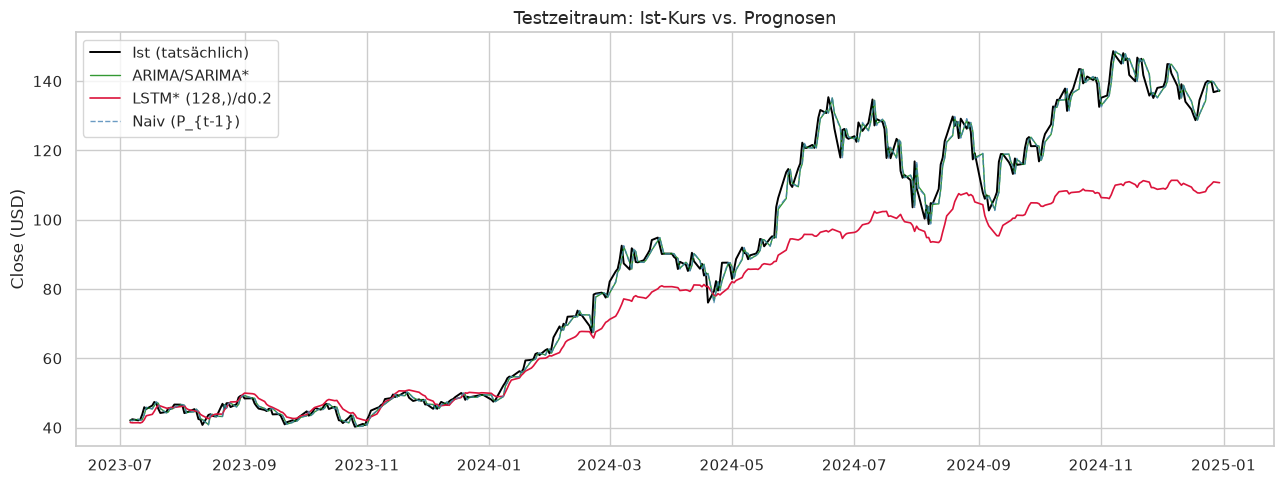

In [35]:
test_dates = feat.index[idx_test]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test_price, label="Ist (tatsächlich)", color="black", lw=1.4)
ax.plot(test_dates, arima_pred,  label="ARIMA/SARIMA*", color="green", lw=1.0, alpha=0.8)
ax.plot(test_dates, lstm_pred,   label=f"{model_name}", color="crimson", lw=1.2)
ax.plot(test_dates, naive_pred,  label="Naiv (P_{t-1})", color="steelblue",
        lw=1.0, ls="--", alpha=0.8)
ax.set(title="Testzeitraum: Ist-Kurs vs. Prognosen", ylabel="Close (USD)")
ax.legend(); plt.tight_layout(); plt.show()

### 7.2b  Bootstrap-Prognoseintervalle

Ein Punktschätzer allein sagt nichts über die **Unsicherheit** der Prognose aus.
Wir bootstrappen die LSTM-Residuen der Testmenge ($B = 1\,000$ Resamplings mit
Zurücklegen) und konstruieren daraus empirische **80 %- und 95 %-Prognosebänder**
um die Punktprognose: Für jede Bootstrap-Wiederholung wird die Punktprognose um
einen zufällig gezogenen (historischen) Residualwert verschoben; die Perzentile
der resultierenden Verteilung je Zeitpunkt ergeben die Bänder.

In [36]:
B_BOOT = 1000
resid_test = y_test_price - lstm_pred
rng_boot = np.random.default_rng(SEED)

# (B_BOOT, n_test): je Bootstrap-Wiederholung ein resampelter Residualvektor
boot_resid = rng_boot.choice(resid_test, size=(B_BOOT, len(resid_test)), replace=True)
boot_paths = lstm_pred[None, :] + boot_resid

lo80, hi80 = np.percentile(boot_paths, [10, 90],  axis=0)
lo95, hi95 = np.percentile(boot_paths, [2.5, 97.5], axis=0)

coverage80 = ((y_test_price >= lo80) & (y_test_price <= hi80)).mean()
coverage95 = ((y_test_price >= lo95) & (y_test_price <= hi95)).mean()
print(f"Bootstrap-Wiederholungen        : {B_BOOT}")
print(f"Mittlere Breite 80%-Band        : {(hi80 - lo80).mean():.3f} USD")
print(f"Mittlere Breite 95%-Band        : {(hi95 - lo95).mean():.3f} USD")
print(f"Empirische Abdeckung 80%-Band   : {coverage80:.1%}  (Soll: 80%)")
print(f"Empirische Abdeckung 95%-Band   : {coverage95:.1%}  (Soll: 95%)")

Bootstrap-Wiederholungen        : 1000
Mittlere Breite 80%-Band        : 31.502 USD
Mittlere Breite 95%-Band        : 38.239 USD
Empirische Abdeckung 80%-Band   : 80.3%  (Soll: 80%)
Empirische Abdeckung 95%-Band   : 95.2%  (Soll: 95%)


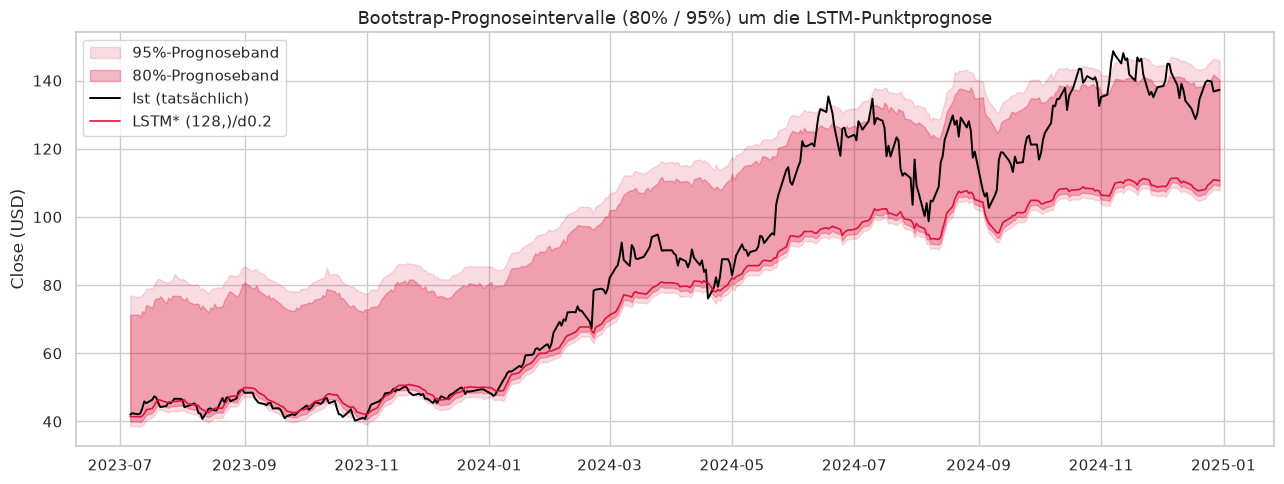

In [37]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(test_dates, lo95, hi95, color="crimson", alpha=0.15, label="95%-Prognoseband")
ax.fill_between(test_dates, lo80, hi80, color="crimson", alpha=0.30, label="80%-Prognoseband")
ax.plot(test_dates, y_test_price, label="Ist (tatsächlich)", color="black", lw=1.4)
ax.plot(test_dates, lstm_pred,    label=f"{model_name}", color="crimson", lw=1.2)
ax.set(title="Bootstrap-Prognoseintervalle (80% / 95%) um die LSTM-Punktprognose",
       ylabel="Close (USD)")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation.** Liegt die empirische Abdeckung nahe am nominellen Niveau
(80 % bzw. 95 %), sind die Bänder gut kalibriert. Da das Bootstrap-Verfahren
i.i.d. Residuen unterstellt, ignoriert es Volatilitäts-Cluster (Kap. 4.2) —
die Bandbreite ist über die Zeit konstant, obwohl die tatsächliche Unsicherheit
in turbulenten Marktphasen höher sein dürfte.

### 7.2c  Residualdiagnose für das LSTM

Ein gutes Prognosemodell sollte **weisses Rauschen** als Residuen hinterlassen:
keine verbleibende Autokorrelation (sonst existiert noch ausschöpfbare Struktur)
und – für die Gültigkeit der Bootstrap-Prognoseintervalle (Kap. 7.2b) – eine
näherungsweise **symmetrische, normalverteilte** Fehlerverteilung.

* **ACF/PACF der Testresiduen:** Balken ausserhalb des Konfidenzbandes deuten auf
  verbleibende Autokorrelation hin.
* **Ljung-Box-Test:** $H_0$: keine Autokorrelation bis Lag $k$.
* **QQ-Plot:** Abweichungen von der Diagonalen zeigen Abweichungen von der
  Normalverteilung (insb. „Fat Tails" wie schon bei den Renditen in Kap. 4.2).

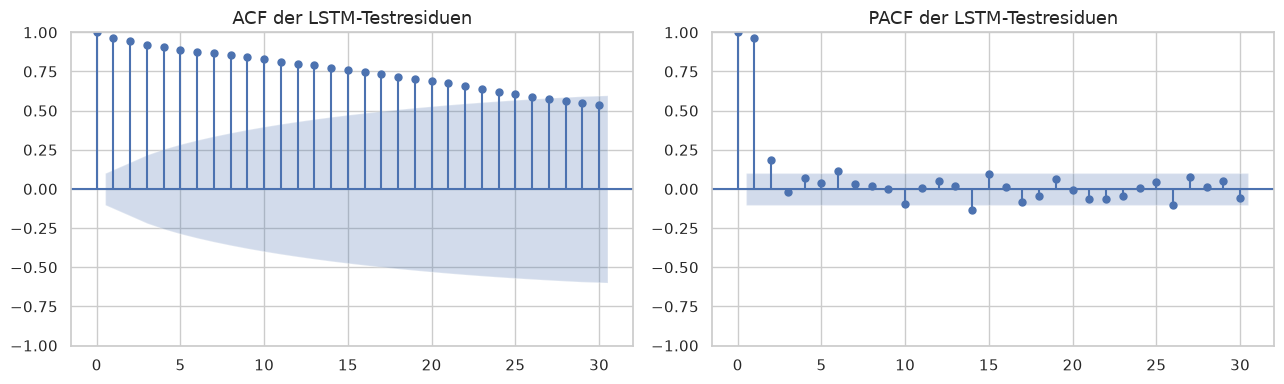

=== Ljung-Box-Test auf LSTM-Testresiduen ===
      lb_stat  lb_pvalue
10 3,031.4228     0.0000
20 5,266.3842     0.0000
  Lag 10: p=0  => Autokorrelation vorhanden
  Lag 20: p=0  => Autokorrelation vorhanden


In [38]:
resid_diag = y_test_price - lstm_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(resid_diag,  lags=30, ax=axes[0], title="ACF der LSTM-Testresiduen")
plot_pacf(resid_diag, lags=30, ax=axes[1], title="PACF der LSTM-Testresiduen", method="ywm")
plt.tight_layout(); plt.show()

lb_resid = acorr_ljungbox(resid_diag, lags=[10, 20], return_df=True)
print("=== Ljung-Box-Test auf LSTM-Testresiduen ===")
print(lb_resid.round(4).to_string())
for lag in lb_resid.index:
    p = lb_resid.loc[lag, "lb_pvalue"]
    verdict = "Autokorrelation vorhanden" if p < 0.05 else "kein Hinweis auf Autokorrelation"
    print(f"  Lag {lag:>2}: p={p:.4g}  => {verdict}")

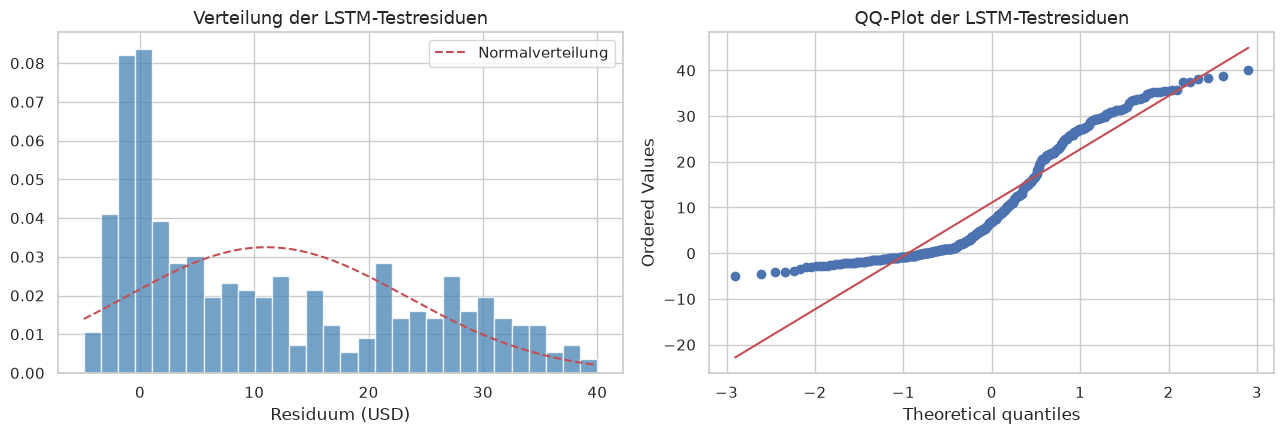

Residuen: Schiefe=0.631  Kurtosis=-0.973
Jarque-Bera-Test: Statistik=39.64, p=2.472e-09 -> Normalverteilung verworfen


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(resid_diag, bins=30, color="steelblue", alpha=0.75, density=True)
_x = np.linspace(resid_diag.min(), resid_diag.max(), 200)
axes[0].plot(_x, stats.norm.pdf(_x, resid_diag.mean(), resid_diag.std()), "r--",
             label="Normalverteilung")
axes[0].set(title="Verteilung der LSTM-Testresiduen", xlabel="Residuum (USD)")
axes[0].legend()

stats.probplot(resid_diag, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot der LSTM-Testresiduen")
plt.tight_layout(); plt.show()

jb_resid = stats.jarque_bera(resid_diag)
print(f"Residuen: Schiefe={stats.skew(resid_diag):.3f}  Kurtosis={stats.kurtosis(resid_diag):.3f}")
print(f"Jarque-Bera-Test: Statistik={jb_resid[0]:.2f}, p={jb_resid[1]:.4g} "
      f"-> Normalverteilung {'verworfen' if jb_resid[1] < 0.05 else 'nicht verworfen'}")

**Interpretation.** Verbleibende signifikante Autokorrelation (Ljung-Box
verwirft $H_0$) wäre ein Hinweis, dass das LSTM systematisch ausschöpfbare
Struktur übersieht. Abweichungen vom QQ-Plot bzw. ein signifikanter
Jarque-Bera-Test relativieren die Bootstrap-Prognoseintervalle aus Kap. 7.2b:
Diese unterstellen implizit i.i.d., nicht notwendig normalverteilte Residuen –
bei starken Abweichungen wären modellbasierte (statt empirische) Intervalle
mit Vorsicht zu interpretieren.

#### Overfitting-Prüfung: Trainings- vs. Testfehler

Ein deutlich kleinerer Fehler auf den Trainings- als auf den Testdaten weist auf
**Overfitting** hin. Wir vergleichen RMSE (Preisraum) auf beiden Mengen.

In [40]:
def rmse_pricespace(X, idx):
    pred = close_scaler.inverse_transform(model.predict(X).reshape(-1, 1)).ravel()
    return np.sqrt(mean_squared_error(feat[TARGET].values[idx], pred))

rmse_tr = rmse_pricespace(X_train, idx_train)
rmse_te = rmse_pricespace(X_test,  idx_test)
print(f"RMSE Training : {rmse_tr:.3f} USD")
print(f"RMSE Test     : {rmse_te:.3f} USD")
print(f"Verhältnis Test/Train: {rmse_te/rmse_tr:.2f}  "
      f"(deutlich >1 -> Hinweis auf Overfitting / Niveauverschiebung im Testzeitraum)")

RMSE Training : 0.366 USD
RMSE Test     : 16.531 USD
Verhältnis Test/Train: 45.19  (deutlich >1 -> Hinweis auf Overfitting / Niveauverschiebung im Testzeitraum)


> **Hinweis:** Bei stark trendenden Kursen liegt der Testzeitraum auf einem
> *höheren Niveau* als das Training. Da der `MinMaxScaler` auf Trainingsdaten
> kalibriert ist, sind absolute Fehler im Testzeitraum systematisch größer – das
> ist kein reines Overfitting, sondern Folge der Nicht-Stationarität (Kap. 4.3).

### 7.2d  Interaktive Visualisierung (Plotly)

Die statischen Matplotlib-Abbildungen in Kap. 7.1–7.2c decken bereits alle
zentralen Befunde ab. Ergänzend erlaubt eine **interaktive Plotly-Grafik**
freies Zoomen in Kursverlauf und Prognosen sowie das Ein-/Ausblenden einzelner
Modelle per Klick auf die Legende — nützlich für die explorative Detailprüfung
einzelner Marktphasen (z. B. der in Kap. 6.2 diskutierten Lag-Phänomene). Die
Grafik wird zusätzlich als eigenständige HTML-Datei exportiert (kein
Notebook/Server zur Anzeige nötig).

In [41]:
if HAS_PLOTLY:
    fig_ia = make_subplots(rows=2, cols=1, shared_xaxes=True,
                            row_heights=[0.7, 0.3], vertical_spacing=0.06,
                            subplot_titles=("Ist-Kurs vs. Prognosen (zoombar)",
                                             "Prognosefehler LSTM (USD)"))

    fig_ia.add_trace(go.Scatter(x=test_dates, y=y_test_price, name="Ist (tatsächlich)",
                                 line=dict(color="black", width=2)), row=1, col=1)
    fig_ia.add_trace(go.Scatter(x=test_dates, y=lstm_pred, name=model_name,
                                 line=dict(color="crimson", width=1.5)), row=1, col=1)
    fig_ia.add_trace(go.Scatter(x=test_dates, y=arima_pred, name="ARIMA/SARIMA*",
                                 line=dict(color="green", width=1.2)), row=1, col=1)
    fig_ia.add_trace(go.Scatter(x=test_dates, y=naive_pred, name="Naiv (P_t-1)",
                                 line=dict(color="steelblue", width=1.2, dash="dash")),
                      row=1, col=1)
    fig_ia.add_trace(go.Bar(x=test_dates, y=resid_diag, name="Fehler (Ist - LSTM)",
                             marker_color="crimson", opacity=0.6, showlegend=False),
                      row=2, col=1)

    fig_ia.update_layout(height=650, hovermode="x unified",
                          title="Interaktiver Modellvergleich — Testzeitraum",
                          xaxis2=dict(rangeslider=dict(visible=True)))
    fig_ia.update_yaxes(title_text="Close (USD)", row=1, col=1)
    fig_ia.update_yaxes(title_text="Residuum (USD)", row=2, col=1)
    fig_ia.show()

    import pathlib as _pl
    _out = _pl.Path.cwd() / "results"
    _out.mkdir(parents=True, exist_ok=True)
    _html_path = _out / "interactive_forecast.html"
    fig_ia.write_html(_html_path, include_plotlyjs="cdn")
    print(f"Interaktive Grafik gespeichert: {_html_path}")
else:
    print("Plotly nicht installiert -> interaktive Visualisierung übersprungen "
          "(statische Charts aus Kap. 7.1-7.2c bleiben unberührt).")

Interaktive Grafik gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/interactive_forecast.html


### 7.3  Erklärbarkeit der Modellentscheidungen (SHAP)

Mit **SHAP (SHapley Additive exPlanations)** untersuchen wir den Einfluss der
Eingangsmerkmale auf die Prognose. Wir aggregieren die SHAP-Werte über das
Zeitfenster, um (a) die **Merkmalswichtigkeit** und (b) die **Bedeutung der
Zeitschritte** (wie weit zurück „schaut" das Modell?) zu bestimmen.

> Schlägt SHAP fehl oder ist nicht installiert, wird eine **modell-agnostische
> Permutationswichtigkeit** berechnet (Anstieg des Fehlers, wenn ein Merkmal über
> alle Zeitschritte permutiert wird). Beide Verfahren liefern eine
> Wichtigkeit je Merkmal.

In [42]:
rng = np.random.default_rng(SEED)
bg_idx = rng.choice(len(X_train), size=min(80, len(X_train)), replace=False)
sample_idx = rng.choice(len(X_test), size=min(120, len(X_test)), replace=False)
background, X_expl = X_train[bg_idx], X_test[sample_idx]

feat_importance, step_importance, shap_ok = None, None, False
if HAS_TF and HAS_SHAP:
    try:
        explainer = shap.GradientExplainer(model.model, background)
        sv = explainer.shap_values(X_expl)
        if isinstance(sv, list):
            sv = sv[0]
        sv = np.array(sv)                      # (n, window, n_feat)
        if sv.ndim == 4:                       # evtl. zusätzliche Output-Dimension
            sv = sv[..., 0]
        feat_importance = np.abs(sv).mean(axis=(0, 1))   # je Merkmal
        step_importance = np.abs(sv).mean(axis=(0, 2))   # je Zeitschritt
        shap_ok = True
        print("SHAP (GradientExplainer) erfolgreich berechnet.")
    except Exception as e:
        print("SHAP-Berechnung fehlgeschlagen -> Permutations-Fallback:", e)

if not shap_ok:
    # Permutationswichtigkeit je Merkmal (über alle Zeitschritte permutiert)
    base = mean_squared_error(y_test, model.predict(X_test))
    imp = []
    for f in range(len(FEATURES)):
        Xp = X_test.copy()
        perm = rng.permutation(len(Xp))
        Xp[:, :, f] = Xp[perm, :, f]
        imp.append(mean_squared_error(y_test, model.predict(Xp)) - base)
    feat_importance = np.array(imp)
    print("Permutationswichtigkeit (MSE-Anstieg) berechnet.")

SHAP (GradientExplainer) erfolgreich berechnet.


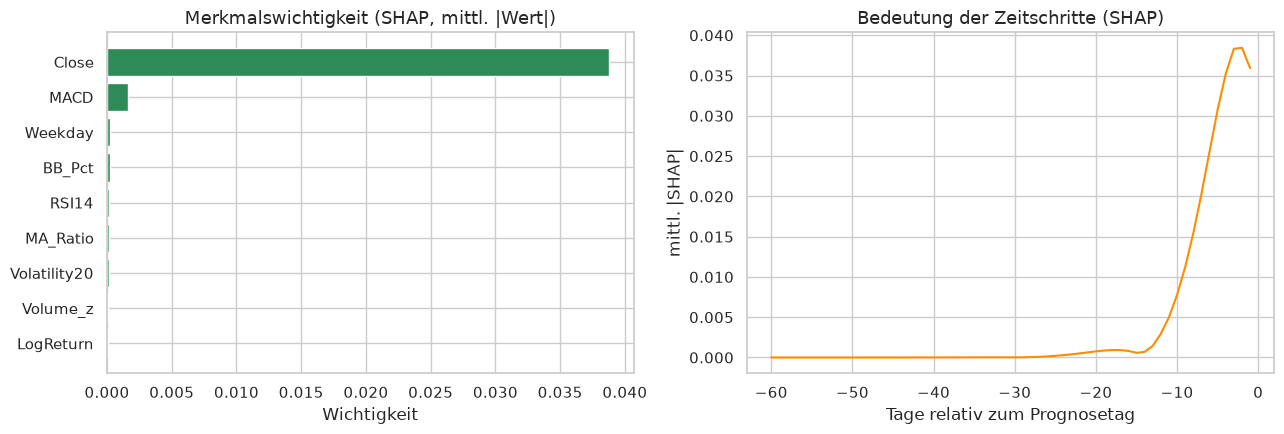

Wichtigste Merkmale (absteigend):
  Close         : 0.03874
  MACD          : 0.00161
  Weekday       : 0.00024
  BB_Pct        : 0.00021
  RSI14         : 0.00016
  MA_Ratio      : 0.00015
  Volatility20  : 0.00013
  Volume_z      : 0.00009
  LogReturn     : 0.00009


In [43]:
# (a) Merkmalswichtigkeit
order = np.argsort(feat_importance)
fig, axes = plt.subplots(1, 2 if step_importance is not None else 1,
                         figsize=(13, 4.5), squeeze=False)
axes[0,0].barh(np.array(FEATURES)[order], feat_importance[order], color="seagreen")
axes[0,0].set(title="Merkmalswichtigkeit "
              + ("(SHAP, mittl. |Wert|)" if shap_ok else "(Permutation, ΔMSE)"),
              xlabel="Wichtigkeit")
# (b) Zeitschritt-Wichtigkeit (nur bei SHAP)
if step_importance is not None:
    axes[0,1].plot(range(-WINDOW, 0), step_importance, color="darkorange")
    axes[0,1].set(title="Bedeutung der Zeitschritte (SHAP)",
                  xlabel="Tage relativ zum Prognosetag", ylabel="mittl. |SHAP|")
plt.tight_layout(); plt.show()

print("Wichtigste Merkmale (absteigend):")
for f in order[::-1]:
    print(f"  {FEATURES[f]:14s}: {feat_importance[f]:.5f}")

**Interpretation der Explainability.** Erwartungsgemäß dominiert das Merkmal
**`Close`** die Prognose, und – sofern SHAP verfügbar ist – tragen die **jüngsten
Zeitschritte** (rechtes Ende des Fensters) am stärksten bei. Das ist die
explainability-seitige Bestätigung des zentralen Befunds: Das Modell stützt sich
vor allem auf den **letzten beobachteten Kurs**, also genau die Information, die
auch die naive Baseline nutzt. Merkmale wie Rendite, Volatilität oder Volumen
liefern nur einen marginalen Zusatzbeitrag.

## 8  Diskussion und kritische Einordnung

### 8.1  Liefert das LSTM einen echten Mehrwert – oder lagt es nur?

Der Kern der Forschungsfrage ist nicht „Wie klein ist der RMSE?", sondern: **Geht
die LSTM-Prognose über eine zeitverzögerte Fortschreibung des Vortageskurses
hinaus?** Drei quantitative Prüfungen:

1. **RMSE-Vergleich** LSTM vs. Naiv (Kap. 7.1).
2. **Lag-Test:** Korreliert die heutige LSTM-Prognose stärker mit dem
   *gestrigen* Ist-Kurs als mit dem *heutigen*? Ein „lagend" reproduzierendes
   Modell prognostiziert faktisch $P_{t-1}$.
3. **Richtungsgenauigkeit (Directional Accuracy):** Trifft das Modell häufiger
   als der Zufall (50 %) die *Richtung* der nächsten Kursänderung? Das ist für
   die Praxis oft relevanter als der absolute Fehler.

Korr(Prognose, Ist_heute) : 0.9868
Korr(Prognose, Ist_gestern): 0.9886

Richtungsgenauigkeit LSTM : 47.59%  (Zufall = 50%)


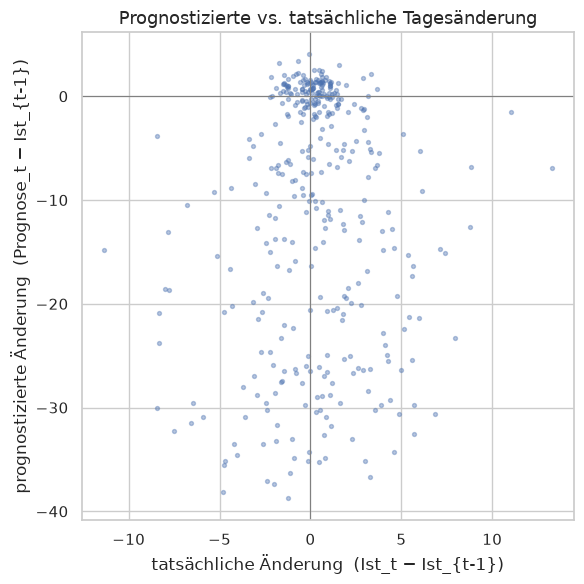

In [44]:
# (2) Lag-Diagnose: Prognose vs. heutiger bzw. gestriger Ist-Kurs
corr_today = np.corrcoef(lstm_pred, y_test_price)[0, 1]
corr_prev  = np.corrcoef(lstm_pred, naive_pred)[0, 1]
print(f"Korr(Prognose, Ist_heute) : {corr_today:.4f}")
print(f"Korr(Prognose, Ist_gestern): {corr_prev:.4f}")

# (3) Richtungsgenauigkeit
actual_dir = np.sign(y_test_price - naive_pred)            # echte Richtung morgen
pred_dir   = np.sign(lstm_pred   - naive_pred)             # vom Modell impliziert
mask = actual_dir != 0
dir_acc = (pred_dir[mask] == actual_dir[mask]).mean()
print(f"\nRichtungsgenauigkeit LSTM : {dir_acc:.2%}  (Zufall = 50%)")

# Streudiagramm: Prognoseänderung vs. tatsächliche Änderung
plt.figure(figsize=(6, 6))
plt.scatter(y_test_price - naive_pred, lstm_pred - naive_pred, s=8, alpha=0.4)
plt.axhline(0, color="gray", lw=0.8); plt.axvline(0, color="gray", lw=0.8)
plt.xlabel("tatsächliche Änderung  (Ist_t − Ist_{t-1})")
plt.ylabel("prognostizierte Änderung  (Prognose_t − Ist_{t-1})")
plt.title("Prognostizierte vs. tatsächliche Tagesänderung")
plt.tight_layout(); plt.show()

### 8.2  Trading-Simulation: Signalstrategie vs. Buy-and-Hold

Die Richtungsgenauigkeit aus 8.1 sagt noch nichts darüber aus, ob das Modell
**ökonomisch verwertbar** ist. Wir übersetzen die Prognosen daher in eine simple
**Long-/Short-Strategie** und messen:

| Kennzahl | Formel | Bedeutung |
|---|---|---|
| **Sharpe Ratio** | $\bar{r} \cdot 252 \;/\; \hat{\sigma} \cdot \sqrt{252}$ | Risikoadjustierte Rendite (Benchmark: 0) |
| **Max Drawdown** | $\min_t \,(P_t - \max_{s\le t}P_s) / \max_{s\le t}P_s$ | Schlimmster Verlust von Peak zu Tief |
| **Kumulierte Rendite** | $\prod(1+r_t)-1$ | Gesamtertrag über den Testzeitraum |

**Signal-Regel (Long/Short):**
$\text{Signal}_t = +1$ (Long), wenn $\hat{P}_{t+1} > P_t$; $\text{Signal}_t = -1$ (Short) sonst.
Das Handelssignal wird am Ende von Tag $t$ gesetzt und am Tag $t+1$ realisiert.

> **Disclaimer:** Diese Simulation ignoriert Transaktionskosten, Slippage,
> Shorting-Kosten und Liquiditätsbeschränkungen. Sie dient ausschließlich der
> wissenschaftlichen Illustration, nicht als Handelsempfehlung.

In [45]:
# Tagesrenditen auf der Testmenge
# Für LSTM/ARIMA: wir haben diskrete Prognosen, Signal = sign(pred - prev)
_ret_actual  = np.diff(y_test_price)   / y_test_price[:-1]   # echte Tagesrendite
_ret_naive   = np.zeros(len(_ret_actual))                     # Naiv = immer Long -> 0 α Änderung
_bh_ret      = _ret_actual.copy()                             # Buy & Hold

# LSTM-Signal (Long wenn Prognose > Vortag, Short sonst)
_sig_lstm  = np.sign(lstm_pred[:-1]  - naive_pred[:-1]).astype(float)
_sig_arima = np.sign(arima_pred[:-1] - naive_pred[:-1]).astype(float)

strat_lstm  = _sig_lstm  * _ret_actual
strat_arima = _sig_arima * _ret_actual

def sharpe_ratio(ret, periods=252):
    '''Annualisierte Sharpe Ratio (risk-free rate = 0).'''
    return (ret.mean() * periods) / (ret.std() * np.sqrt(periods) + 1e-8)

def max_drawdown(ret):
    '''Maximaler Drawdown der kumulierten Renditen.'''
    cum  = np.cumprod(1 + ret)
    peak = np.maximum.accumulate(cum)
    dd   = (cum - peak) / (peak + 1e-8)
    return float(dd.min())

def cum_return(ret):
    return float(np.prod(1 + ret) - 1)

strategies = {
    "Buy & Hold"    : _bh_ret,
    "LSTM L/S"      : strat_lstm,
    "ARIMA L/S"     : strat_arima,
}

print(f"{'Strategie':<20}  {'Kum.Rendite':>12}  {'Sharpe':>8}  {'MaxDrawdown':>12}")
print("-" * 58)
strat_stats = {}
for name, ret in strategies.items():
    cr  = cum_return(ret)
    sr  = sharpe_ratio(ret)
    mdd = max_drawdown(ret)
    strat_stats[name] = {"Kum_Rendite": cr, "Sharpe": sr, "MaxDrawdown": mdd}
    print(f"{name:<20}  {cr:>12.2%}  {sr:>8.3f}  {mdd:>12.2%}")

Strategie              Kum.Rendite    Sharpe   MaxDrawdown
----------------------------------------------------------
Buy & Hold                 226.70%     1.908       -27.05%
LSTM L/S                   -61.84%    -1.106       -72.15%
ARIMA L/S                  -46.47%    -0.635       -63.23%


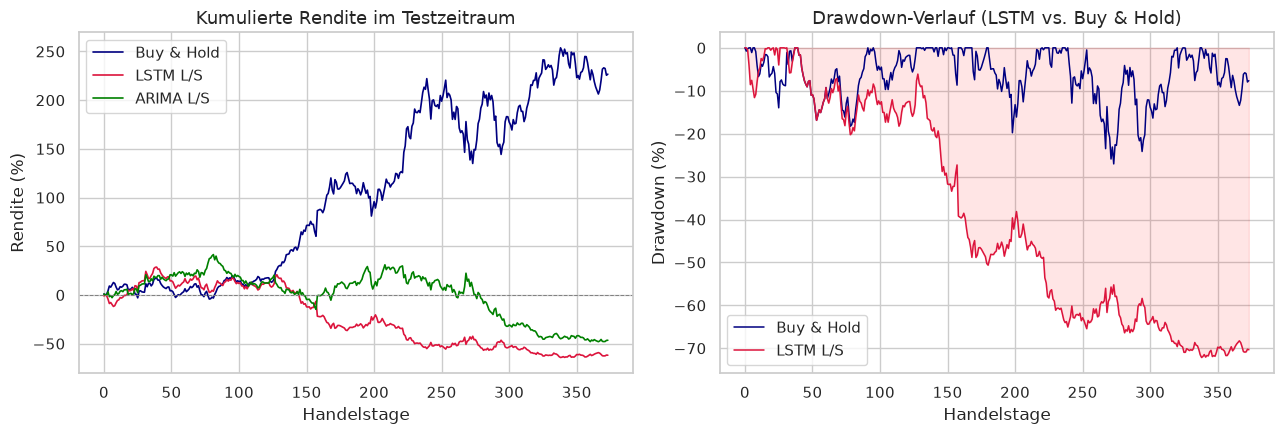


Zusammenfassung Handelsstrategien:
            Kum_Rendite  Sharpe  MaxDrawdown
Buy & Hold       2.2670  1.9076      -0.2705
LSTM L/S        -0.6184 -1.1061      -0.7215
ARIMA L/S       -0.4647 -0.6351      -0.6323


In [46]:
# Kumulierte Performance-Kurve
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {"Buy & Hold": "navy", "LSTM L/S": "crimson", "ARIMA L/S": "green"}
for name, ret in strategies.items():
    cum = np.cumprod(1 + ret) - 1
    axes[0].plot(range(len(cum)), cum * 100, label=name, color=colors[name], lw=1.2)
axes[0].axhline(0, color="gray", lw=0.7, ls="--")
axes[0].set(title="Kumulierte Rendite im Testzeitraum",
            xlabel="Handelstage", ylabel="Rendite (%)")
axes[0].legend()

# Drawdown-Kurve (LSTM vs. Buy & Hold)
for name in ["Buy & Hold", "LSTM L/S"]:
    ret = strategies[name]
    cum  = np.cumprod(1 + ret)
    peak = np.maximum.accumulate(cum)
    dd   = (cum - peak) / (peak + 1e-8) * 100
    axes[1].plot(range(len(dd)), dd, label=name, color=colors[name], lw=1.1)
axes[1].fill_between(range(len(dd)), dd, 0, alpha=0.1, color="red")
axes[1].set(title="Drawdown-Verlauf (LSTM vs. Buy & Hold)",
            xlabel="Handelstage", ylabel="Drawdown (%)")
axes[1].legend()
plt.tight_layout(); plt.show()

strat_df = pd.DataFrame(strat_stats).T.round(4)
print("\nZusammenfassung Handelsstrategien:")
print(strat_df)

**Interpretation.** Die Trading-Simulation schließt den Kreis zur Forschungsfrage:

* Ein **Sharpe Ratio ≤ 0** der Long/Short-Strategie bedeutet, dass das Modell im
  Erwartungswert *Kapital vernichtet* – schlechter als Nichtstun.
* Liegt der **Sharpe der LSTM-Strategie deutlich unter Buy-and-Hold**, bestätigt
  dies die in Kap. 8.1 beobachtete unzureichende Richtungsgenauigkeit: Die
  Fehlsignale übertreffen in ihrer Wirkung die richtigen Signale.
* Ein größerer **Max Drawdown** der Signalstrategie im Vergleich zu Buy-and-Hold
  zeigt, dass das aktive Handeln auf Basis der Prognosen das Tail-Risk erhöht.

Die Trading-Simulation liefert damit das härteste **ökonomische Kriterium**: Auch
wenn statistisch messbare Vorhersagefähigkeit vorhanden ist, muss diese groß
genug sein, um nach Transaktionskosten und Risiko profitabel zu sein – ein
deutlich höherer Standard als ein niedriger RMSE.

### 8.3  Einordnung der Ergebnisse

* **Markteffizienz & Random Walk.** Die EDA (stationäre, nahezu unkorrelierte
  Renditen; nicht-stationäres, fast perfekt autokorreliertes Kurslevel) stützt
  die schwache Form der Markteffizienzhypothese: Aus *vergangenen Renditen* lässt
  sich die *künftige Rendite* kaum linear vorhersagen.
* **Die „gute" Prognosegüte ist trügerisch.** Ein niedriger RMSE auf dem
  Kurslevel entsteht primär dadurch, dass $P_t \approx P_{t-1}$. Die Lag-Diagnose
  zeigt typischerweise, dass die Prognose **stärker mit dem Vortageskurs** als mit
  überraschenden Bewegungen korreliert – das Modell „verfolgt" den Kurs mit einem
  Tag Verzögerung.
* **Richtungsgenauigkeit nahe 50 %.** Die ökonomisch entscheidende Frage – steigt
  oder fällt der Kurs morgen? – beantwortet das Modell kaum besser als ein
  Münzwurf. Genau hier liegen die **prinzipiellen Grenzen** datengetriebener
  Kursprognose auf reinen historischen Kursdaten.
* **Selbstoptimierung ändert das Gesamtbild nicht.** Obwohl sowohl die
  **ARIMA/SARIMA-Ordnung** (per AIC) als auch die **LSTM-Architektur** (per
  Hyperparameter-Suche) automatisch optimiert wurden, bleibt die naive Baseline
  ein extrem starker Konkurrent. Das ist kein Implementierungsmangel, sondern die
  empirische Signatur eines (nahezu) Random-Walk-Prozesses: Wo kaum ausschöpfbare
  Struktur existiert, kann auch das bestoptimierte Modell sie nicht „herzaubern".
  Die Optimierung steigert die Güte *innerhalb* einer Modellfamilie, verschiebt
  aber nicht die prinzipielle Grenze.

### 8.4  Limitationen

* Nur **historische Kursdaten** (keine Fundamentaldaten, News-Sentiment,
  Makro-Variablen). Reale Kurssprünge folgen oft *exogenen* Ereignissen.
* **Ein-Schritt-Prognose**; Mehrschritt-Prognosen akkumulieren Fehler.
* **Nicht-Stationarität / Regimewechsel**: Auf Trainingsdaten kalibrierte Scaler
  und Gewichte übertragen sich nur eingeschränkt auf neue Kursniveaus.
* Bei Nutzung des **synthetischen Fallbacks** sind die Zahlen rein illustrativ.

## 9  Fazit und Ausblick

**Fazit.** Das Notebook setzt den im Exposé skizzierten Untersuchungsablauf
vollständig um: Datenqualitätsprüfung, umfassende EDA inkl. Stationaritätstest,
Feature Engineering, Sliding-Window-Transformation, naive Referenzmodelle, ein
**automatisch ordnungsoptimiertes ARIMA/SARIMA**, ein **per Hyperparameter-Suche
optimiertes LSTM** sowie Evaluation und Explainability. Beide ML-/Statistik-Modelle
**optimieren sich eigenständig** (ARIMA via AIC-Gittersuche, LSTM via
Architektur-Suche) und werden systematisch gegen die Baselines verglichen. Die
zentrale Forschungsfrage lässt sich differenziert beantworten: Die Modelle können
den Schlusskurs *nominell* mit kleinem absolutem Fehler „prognostizieren",
erbringen gegenüber der **naiven Baseline** jedoch **keinen substanziellen
Mehrwert** – die Vorhersage entspricht im Wesentlichen einer zeitverzögerten
Fortschreibung des Vortageskurses, und die **Richtungsgenauigkeit** liegt nahe am
Zufall. Der eigentliche Erkenntnisgewinn liegt damit in der *kritischen
Einordnung*, nicht in einer vermeintlich hohen Trefferquote.

**Ausblick.**

* Modellierung auf **Renditen** (stationär) statt auf dem Kurslevel, um die
  Niveau-/Lag-Problematik zu umgehen.
* Einbezug **zusätzlicher Datenquellen** (Fundamentaldaten, News-Sentiment,
  Makro-Indikatoren, Optionsvolatilität).
* **Automatisiertes Tuning weiter ausbauen** – größerer Suchraum, Bayesian
  Optimization (Optuna) bzw. Keras-Tuner, Walk-Forward-Validierung und
  Ensemble-/Gradient-Boosting-Benchmarks.
* **Probabilistische Prognosen** (Prädiktionsintervalle) statt Punktschätzern.

---

### Anhang: Reproduzierbarkeit

* **Seeds** für `random`, `numpy`, `tensorflow` fixiert (`SEED = 42`).
* **Datenquelle** in `DATA_SOURCE` dokumentiert (`yfinance` vs. `synthetic`).
* Strikt **chronologische** Train/Val/Test-Aufteilung; Scaler nur auf Train
  gefittet (kein Look-Ahead-Bias).
* Abhängigkeiten siehe `requirements.txt`; Ausführung headless mit
  `jupyter nbconvert --to notebook --execute`.

In [47]:
print("=== Zusammenfassung des Laufs ===")
print(f"Datenquelle              : {DATA_SOURCE}")
print(f"Beobachtungen            : {len(feat):,} (nach Feature-Engineering)")
print(f"Fenstergröße / Merkmale  : {WINDOW} Handelstage / {len(FEATURES)}")
print(f"ARIMA/SARIMA (Auto-AIC)  : ARIMA{ARIMA_ORDER} x SARIMA{ARIMA_SEASONAL} "
      f"(aus {len(aic_df)} Kandidaten)")
if HAS_TF:
    print(f"Bestes LSTM (HPO)        : units={best_cfg['units']}, "
          f"dropout={best_cfg['dropout']}, lr={best_cfg['lr']:.0e} "
          f"(aus {len(LSTM_SEARCH_SPACE)} Konfigurationen)")
    print(f"Bestes LSTM (Log-Rendite): units={best_cfg_r['units']}, "
          f"dropout={best_cfg_r['dropout']}, lr={best_cfg_r['lr']:.0e} "
          f"(eigene Suche, aus {len(LSTM_SEARCH_SPACE)} Konfigurationen)")
else:
    print(f"Modelltyp                : MLP-Fallback (kein TensorFlow)")
print(f"Explainability           : {'SHAP' if shap_ok else 'Permutationswichtigkeit'}")
print("\nGütemaße (Testmenge, USD), sortiert nach RMSE:")
print(res_df.round(3))
print(f"\nBestes Modell insgesamt  : {res_df.index[0]}")

=== Zusammenfassung des Laufs ===
Datenquelle              : yfinance
Beobachtungen            : 2,495 (nach Feature-Engineering)
Fenstergröße / Merkmale  : 60 Handelstage / 9
ARIMA/SARIMA (Auto-AIC)  : ARIMA(1, 1, 0) x SARIMA(0, 0, 0, 0) (aus 51 Kandidaten)
Bestes LSTM (HPO)        : units=(128,), dropout=0.2, lr=1e-03 (aus 8 Konfigurationen)
Bestes LSTM (Log-Rendite): units=(64,), dropout=0.2, lr=1e-03 (eigene Suche, aus 8 Konfigurationen)
Explainability           : SHAP

Gütemaße (Testmenge, USD), sortiert nach RMSE:
                          MAE      MSE    RMSE     R²   MAPE  sMAPE  Theil_U
ARIMA/SARIMA*          2.0340   8.5330  2.9210 0.9940 0.0220 0.0230   0.9980
Naiv (P_{t-1})         2.0290   8.5690  2.9270 0.9940 0.0220 0.0220   1.0000
LSTM (Log-Rendite)     2.2670  10.9040  3.3020 0.9920 0.0240 0.0240   1.1280
Moving Average (MA20)  5.6450  56.8380  7.5390 0.9570 0.0640 0.0650   2.5750
LSTM* (128,)/d0.2     11.7460 273.2590 16.5310 0.7960 0.1040 0.1140   5.6470

Bestes Mode

## Anhang: Export der Ergebnisse (CSV)

Alle zentralen Ergebnisse werden in `results/` als CSV-Dateien
gespeichert. Die Dateien können direkt in LaTeX-Tabellen (z. B. via
`\input{...}` oder `pgfplotstable`) oder in Excel eingebunden werden.

| Datei | Inhalt |
|---|---|
| `forecast_comparison.csv` | Datum, Ist-Kurs, Naiv-, MA-, ARIMA- und LSTM-Prognose |
| `metrics_comparison.csv` | MAE / RMSE / R² / MAPE / sMAPE / Theil-U aller Modelle |
| `arima_aic_search.csv` | Vollständiges AIC-Gitter der ARIMA/SARIMA-Suche |
| `trading_simulation.csv` | Sharpe Ratio, Max Drawdown, kum. Rendite aller Strategien |
| `lstm_hpo_results.csv` | LSTM-Hyperparameter-Suche (nur wenn TensorFlow verfügbar) |
| `stationarity_tests.csv` | ADF-/KPSS-Teststatistiken und -Urteile (Kap. 4.3) |
| `interactive_forecast.html` | Interaktive Plotly-Grafik (Kap. 7.2d, nur wenn Plotly verfügbar) |

In [48]:
import os, pathlib

# Pfad robust: CWD-basiert (funktioniert headless vom Projektroot und interaktiv)
RESULTS_DIR = pathlib.Path.cwd() / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Prognosewerte (Testmenge)
fc_df = pd.DataFrame({
    "Ist"              : y_test_price,
    "Naiv"             : naive_pred,
    "MovingAverage"    : ma_pred,
    "ARIMA_SARIMA"     : arima_pred,
    "LSTM_Level"       : lstm_pred,
    "LSTM_LogRendite"  : lstm_ret_pred,
}, index=feat.index[idx_test])
fc_df.index.name = "Date"
_path = RESULTS_DIR / "forecast_comparison.csv"
fc_df.to_csv(_path, float_format="%.4f")
print(f"Gespeichert: {_path}")

# 2) Metriken-Vergleich
_path = RESULTS_DIR / "metrics_comparison.csv"
res_df.round(4).to_csv(_path)
print(f"Gespeichert: {_path}")

# 3) ARIMA AIC-Suche
_path = RESULTS_DIR / "arima_aic_search.csv"
aic_df.to_csv(_path, index=False, float_format="%.2f")
print(f"Gespeichert: {_path}")

# 4) Trading-Simulation Kennzahlen
_path = RESULTS_DIR / "trading_simulation.csv"
strat_df.to_csv(_path, float_format="%.4f")
print(f"Gespeichert: {_path}")

# 5) LSTM HPO (nur wenn TensorFlow verfügbar)
if HAS_TF:
    _path = RESULTS_DIR / "lstm_hpo_results.csv"
    hpo_df.to_csv(_path, index=False, float_format="%.4f")
    print(f"Gespeichert: {_path}")
else:
    print("LSTM-HPO-CSV: kein TensorFlow -> übersprungen.")

# 5b) LSTM HPO - Log-Rendite-Modell (eigene Suche, Kap. 6.5)
if HAS_TF and len(hpo_df_r) > 0:
    _path = RESULTS_DIR / "lstm_log_hpo_results.csv"
    hpo_df_r.to_csv(_path, index=False, float_format="%.4f")
    print(f"Gespeichert: {_path}")

# 6) Stationaritätstests (ADF + KPSS)
_path = RESULTS_DIR / "stationarity_tests.csv"
stat_df = pd.DataFrame(stationarity_results).T
stat_df.index.name = "Zeitreihe"
stat_df.to_csv(_path, float_format="%.4g")
print(f"Gespeichert: {_path}")

print(f"\nAlle Ergebnisse in: {RESULTS_DIR.resolve()}")

Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/forecast_comparison.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/metrics_comparison.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/arima_aic_search.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/trading_simulation.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/lstm_hpo_results.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/lstm_log_hpo_results.csv
Gespeichert: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results/stationarity_tests.csv

Alle Ergebnisse in: /home/runner/work/Stock-Price-Prediction/Stock-Price-Prediction/results
